# Emotional Cues at Different Temporal Positions and User Engagement on TikTok
### How Do People Process and Respond to Emotional Information in Short-Form Videos?

---

## Abstract

This study investigates how **emotional cues embedded at different temporal positions** in
short-form TikTok videos predict user engagement behaviour — operationalised as sharing and
commenting rates — which serve as proxies for **information diffusion and social processing**.

Drawing on dual-process theory and affective computing, we argue that viewers' information
processing strategies depend critically on *both* **which specific emotion** appears in a
video *and* **when** it appears. Three temporal accounts are tested alongside a
**specific-emotion analysis** that identifies which discrete emotions (angry, happy, sad,
fear, surprise, disgust, neutral) drive sharing, commenting, and liking.

Temporal accounts tested:

1. **First-Impression Account** — emotional cues in the opening seconds act as an attention
   gate, determining whether viewers process and propagate the content.
2. **Average-Tone Account** — the sustained emotional climate across the full video shapes
   the overall evaluation and engagement decision.
3. **Recency Account** — an emotional peak near the video's end triggers post-viewing
   sharing or commenting (recency effect on memory and action).

We operationalise these accounts by extracting per-frame emotion features at **3 fps** using
DeepFace, then computing three non-overlapping time-window feature sets per video:

| Window | Definition | Theoretical Account Tested |
|--------|-----------|--------------------------|
| **Early** | First 25 % of frames | First-Impression Account |
| **Whole** | All frames (100 %) | Average-Tone Account |
| **Late**  | Last 25 % of frames | Recency Account |

Predictive models (Linear Regression, Random Forest, Gradient Boosting) are trained
separately on each window's features and evaluated via 5-fold cross-validation.
Comparative R² across windows indicates which temporal position of emotional cueing
most strongly predicts engagement — and thus which account best characterises how
audiences extract and respond to emotional information from social video.

Beyond prediction, we conduct **ablation studies** (isolating visual vs audio channel
contributions), **hierarchical regression** (incremental R² over a popularity baseline),
**cross-window interaction analysis** (emotion narrative arcs), and **mediation analysis**
(emotion → algorithmic reach → engagement) to provide a multi-layered understanding of
how emotional cues shape information processing.

## Dataset
- **N = 5 651 TikTok videos** with extracted emotion features (from 6 408-video corpus; 88.2% coverage)
- Emotion extraction at **3 fps** (high temporal resolution)
- **Emotional cue channels**: 👁 Visual (DeepFace facial emotion, 24 features) + 👂 Audio (librosa acoustic features, 13 features)
- **Primary outcomes**: log(1 + shares), log(1 + comments) — absolute engagement counts
- **Supplementary outcomes**: log(share/view ratio), log(comment/view ratio) — normalised rates

## Pipeline Overview
1. **Section 0** – High-resolution emotion extraction (3 fps, DeepFace)
2. **Section 1** – Data loading & integration (emotion + metadata + emoji + audio)
3. **Section 1C** – Data and feature construction (universe, variables, preprocessing, rationale)
4. **Section 2** – Data cleaning & feature engineering (log outcomes, window features)
5. **Section 3** – Exploratory data analysis (EDA + emotion heatmaps + audio correlations)
6. **Section 4A–D** – Dual-channel joint model (37 features) + feature importance + OLS
6. **Section 4E** – Ablation study: Visual-only vs Audio-only vs Joint
7. **Section 4F** – Hierarchical regression: incremental R² over popularity baseline
8. **Section 4G** – Cross-window emotion interaction analysis
9. **Section 4H** – Mediation analysis: Emotion → Views → Engagement
10. **Section 4I** – Robustness check: engagement ratio outcomes
11. **Section 5** – Visualisations
12. **Section 6** – Summary & conclusions
13. **Section 7** – Discussion: Research question revisited
14. **Section 8** – Limitations & future directions
15. **Section 9** – How the data were obtained


## Section 0 – High-Resolution Video Emotion Extraction

Extract per-frame dominant emotions from every video at **3 fps** using DeepFace.
For each video the following three non-overlapping windows are defined:

- **Early window** – first `EARLY_FRAC` (25 %) of frames
- **Whole window** – all frames
- **Late window**  – last `LATE_FRAC` (25 %) of frames

Per-window features computed:
- `{window}_arousal` – mean arousal score (0–1 scale)
- `{window}_{emotion}_intensity` – fraction of frames with that dominant emotion


In [1]:
import csv
import os
from collections import Counter
import cv2
from deepface import DeepFace
from tqdm import tqdm

# ===== Extraction Configuration =====
FPS                  = 3       # Target sampling rate (frames per second)
EARLY_FRAC           = 0.25    # Early window: first 25% of the video
LATE_FRAC            = 0.25    # Late window: last 25% of the video
CONFIDENCE_THRESHOLD = 10.0    # Minimum DeepFace confidence (%) to accept prediction

VIDEO_DIR     = "run/videos"            # Full-dataset directory (6 408 videos)
OUTPUT_CSV    = "full_visual_results.csv"
EXTRACT_LIMIT = None                    # Set to int (e.g. 200) for a quick test run

# Arousal mapping: emotion label -> continuous score (0-1)
AROUSAL_MAP = {
    "surprise": 0.9, "fear": 0.9, "angry": 0.9,
    "happy":    0.7,
    "neutral":  0.3, "sad": 0.3, "disgust": 0.3,
}

# Canonical emotion name -> output column name
EMOTION_TO_COL = {
    "angry":   "angry_intensity",
    "disgust": "disgust_intensity",
    "fear":    "fear_intensity",
    "happy":   "happiness_intensity",
    "sad":     "sadness_intensity",
    "surprise":"surprise_intensity",
    "neutral": "neutral_intensity",
}


def compute_window_features(frame_emotions: list, prefix: str) -> dict:
    """Compute arousal and per-emotion intensity for a list of frame-level emotions."""
    n = len(frame_emotions)
    if n == 0:
        feats = {f"{prefix}_arousal": 0.3}
        feats.update({f"{prefix}_{col}": 0.0 for col in EMOTION_TO_COL.values()})
        return feats
    arousals = [AROUSAL_MAP.get(e, 0.3) for e in frame_emotions]
    counts   = Counter(frame_emotions)
    feats    = {f"{prefix}_arousal": sum(arousals) / n}
    feats.update({f"{prefix}_{col}": counts.get(emo, 0) / n
                  for emo, col in EMOTION_TO_COL.items()})
    return feats


def analyze_video(video_path: str):
    """Extract multi-window emotion features from a single video file.
    Returns a dict of features, or None if the video cannot be processed.
    """
    cap = cv2.VideoCapture(video_path)
    native_fps   = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if native_fps <= 0 or total_frames <= 0:
        cap.release()
        return None

    duration_s     = total_frames / native_fps
    frame_interval = max(1, int(native_fps / FPS))
    early_end      = int(total_frames * EARLY_FRAC)
    late_start     = int(total_frames * (1 - LATE_FRAC))

    all_emo, early_emo, late_emo = [], [], []
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_interval == 0:
            try:
                res  = DeepFace.analyze(frame, actions=["emotion"],
                                        enforce_detection=False, silent=True)
                dom  = res[0]["dominant_emotion"]
                conf = res[0]["emotion"].get(dom, 0)
                if conf >= CONFIDENCE_THRESHOLD:
                    all_emo.append(dom)
                    if frame_idx <= early_end:
                        early_emo.append(dom)
                    if frame_idx >= late_start:
                        late_emo.append(dom)
            except Exception:
                pass
        frame_idx += 1
    cap.release()

    if not all_emo:
        return None

    counts = Counter(all_emo)
    record = {
        "video_id":         os.path.basename(video_path).replace(".mp4", ""),
        "duration_s":       round(duration_s, 2),
        "frames_analyzed":  len(all_emo),
        "dominant_emotion": counts.most_common(1)[0][0],
        "emotion_variety":  len(set(all_emo)),
    }
    record.update(compute_window_features(early_emo, "early"))
    record.update(compute_window_features(all_emo,   "whole"))
    record.update(compute_window_features(late_emo,  "late"))
    return record


def run_extraction():
    """Run emotion extraction on all videos in VIDEO_DIR and save to OUTPUT_CSV."""
    if not os.path.exists(VIDEO_DIR):
        raise FileNotFoundError(f"Video directory '{VIDEO_DIR}' not found.")
    video_files = sorted(f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4"))
    if EXTRACT_LIMIT:
        video_files = video_files[:EXTRACT_LIMIT]
    if not video_files:
        raise ValueError(f"No .mp4 files found in '{VIDEO_DIR}'")

    dummy = {}
    for pfx in ["early", "whole", "late"]:
        dummy.update(compute_window_features([], pfx))
    fieldnames = ["video_id", "duration_s", "frames_analyzed",
                  "dominant_emotion", "emotion_variety"] + list(dummy.keys())

    results = []
    for fname in tqdm(video_files, desc="Extracting emotions"):
        r = analyze_video(os.path.join(VIDEO_DIR, fname))
        if r:
            results.append(r)

    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)

    print(f"Extraction complete: {len(results)}/{len(video_files)} videos processed.")
    print(f"Output saved to: {OUTPUT_CSV}")
    return results


# ---------------------------------------------------------------------------
# Un-comment to run the full extraction (takes several hours on 6 408 videos).
# run_extraction()
# ---------------------------------------------------------------------------
print("Section 0 ready.")
print(f"  Sampling rate : {FPS} fps")
print(f"  Early window  : first {EARLY_FRAC*100:.0f}% of frames")
print(f"  Late window   : last  {LATE_FRAC*100:.0f}% of frames")
print(f"  Output file   : {OUTPUT_CSV}")


Section 0 ready.
  Sampling rate : 3 fps
  Early window  : first 25% of frames
  Late window   : last  25% of frames
  Output file   : full_visual_results.csv


## Section 1 – Data Loading and Integration


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# ===== Configuration =====
PILOT_MODE  = False   # True -> 50-video pilot;  False -> full 6 408-video dataset
SAMPLE_SIZE = None    # Optional int to cap rows during development

# Extraction parameters (mirrors Section 0; set here so Sections 1-7 run
# independently even when Section 0 is skipped)
FPS        = 3      # Frames-per-second used during video emotion extraction
EARLY_FRAC = 0.25   # Early window: first 25% of frames
LATE_FRAC  = 0.25   # Late window:  last 25% of frames

if PILOT_MODE:
    EMOTION_FILE  = "pilot_visual_results.csv"
    METADATA_FILE = "data/video_metadata_pilot.csv"
else:
    EMOTION_FILE  = "full_visual_results.csv"
    METADATA_FILE = "videos.csv"      # Full TikTok export (6 408 rows)

EMOJI_FILE = "data/video_comment_features.csv"

# Time windows
WINDOWS = ["early", "whole", "late"]

# Per-window emotion intensity column names
EMOTION_BASE = [
    "angry_intensity", "disgust_intensity", "fear_intensity",
    "happiness_intensity", "sadness_intensity",
    "surprise_intensity", "neutral_intensity",
]
EMOTION_COLS_BY_WINDOW = {w: [f"{w}_{c}" for c in EMOTION_BASE] for w in WINDOWS}
AROUSAL_COL            = {w: f"{w}_arousal" for w in WINDOWS}

# "whole" window columns used for data-quality validation
EMOTION_COLS = EMOTION_COLS_BY_WINDOW["whole"]


def validate_data(df, emotion_cols=None):
    """Basic data-quality checks; returns True if all checks pass."""
    if emotion_cols is None:
        emotion_cols = EMOTION_COLS
    issues = []
    if (df["views"] < 0).any():
        issues.append("Negative views found")
    if (df["likes"] > df["views"]).any():
        issues.append("Likes exceed views")
    if (df["shares"] > df["views"]).any():
        issues.append("Shares exceed views")
    if emotion_cols:
        s = df[[c for c in emotion_cols if c in df.columns]].sum(axis=1)
        if not ((s >= 0.95) & (s <= 1.05)).all():
            issues.append("Whole-window emotion intensities do not sum to ~1")
    if issues:
        print("WARNING - Data quality issues:", "; ".join(issues))
        return False
    print("PASS: Data quality checks passed")
    return True


In [3]:
# Load emotion features (output of Section 0 extraction)
emotion_df = pd.read_csv(EMOTION_FILE)
if SAMPLE_SIZE:
    emotion_df = emotion_df.head(SAMPLE_SIZE)
print(f"Emotion data loaded: {len(emotion_df)} videos")
print(emotion_df.head(3))


Emotion data loaded: 5651 videos
              video_id  duration_s  frames_analyzed dominant_emotion  \
0  6968905209095458049       46.70              141              sad   
1  6968999590536219905       57.97              174            angry   
2  6969298511233912066       48.97              147          neutral   

   emotion_variety  early_arousal  whole_arousal  late_arousal  \
0                7         0.6833         0.5709        0.6056   
1                6         0.8455         0.8195        0.7558   
2                7         0.6622         0.6605        0.6389   

   early_angry_intensity  early_disgust_intensity  ...  \
0                 0.0278                   0.0278  ...   
1                 0.3864                   0.0000  ...   
2                 0.1351                   0.0000  ...   

   whole_sadness_intensity  whole_surprise_intensity  whole_neutral_intensity  \
0                   0.3759                    0.0780                   0.1064   
1                 

In [4]:
# Load video metadata
metadata_df = pd.read_csv(METADATA_FILE)

# Full-dataset CSV (videos.csv) uses TikTok export column names; rename to standard labels
if not PILOT_MODE:
    rename_map = {
        "playCount":    "views",
        "diggCount":    "likes",
        "shareCount":   "shares",
        "commentCount": "comments",
        "collectCount": "collects",
    }
    metadata_df = metadata_df.rename(columns=rename_map)

# Optional: limit to the same sample as emotion_df
if SAMPLE_SIZE and "video_id" in emotion_df.columns:
    metadata_df = metadata_df[metadata_df["video_id"].isin(emotion_df["video_id"])]

print(f"Metadata loaded: {len(metadata_df)} videos")
print(metadata_df[["video_id", "views", "likes", "shares", "comments"]].head(3))


Metadata loaded: 6408 videos
              video_id  views  likes  shares  comments
0  7573501045792410888    485     52       0         8
1  7573314488057957650    360     43       0         1
2  7572786666734193928    613     60       0         5


In [5]:
# Load emoji / comment feature data
emoji_df = pd.read_csv(EMOJI_FILE)
print(f"Emoji source file: {len(emoji_df)} rows")


def extract_video_id(url):
    if pd.isna(url) or not isinstance(url, str):
        return None
    return url.split("/video/")[-1].split("?")[0] if "/video/" in url else None


emoji_df["video_id"] = emoji_df["video_url"].apply(extract_video_id)
emoji_df = emoji_df.dropna(subset=["video_id"])

# Deduplicate: sum/average per video_id
if emoji_df["video_id"].duplicated().any():
    emoji_df = (
        emoji_df.groupby("video_id")
        .agg({"total_emoji": "sum",
              "avg_emoji_density": "mean",
              "comment_count": "sum"})
        .reset_index()
    )

# In pilot mode keep only the pilot sample
if PILOT_MODE:
    pilot_ids = set(emotion_df["video_id"].astype(str))
    emoji_df = emoji_df[emoji_df["video_id"].isin(pilot_ids)].copy()
    print(f"Emoji data (pilot subset): {len(emoji_df)} videos")
else:
    print(f"Emoji data: {len(emoji_df)} videos")

print(emoji_df[["video_id", "total_emoji", "avg_emoji_density", "comment_count"]].head(3))


Emoji source file: 5812 rows
Emoji data: 5812 videos
              video_id  total_emoji  avg_emoji_density  comment_count
0  7457743487430135046            2           0.400000              5
1  7466580161543064837            6           0.600000             10
2  7469139129599610118            8           0.727273             11


In [6]:
# Load audio features (extracted by extract_audio_features.py)
AUDIO_FILE = "full_audio_features.csv"

audio_df = pd.read_csv(AUDIO_FILE)
audio_df["video_id"] = audio_df["video_id"].astype(str)
print(f"Audio features loaded: {len(audio_df)} videos")
print(f"Audio feature columns ({len(audio_df.columns)-1}): {[c for c in audio_df.columns if c != 'video_id']}")


Audio features loaded: 5651 videos
Audio feature columns (13): ['audio_tempo', 'audio_rms_energy', 'audio_spec_centroid', 'audio_zcr', 'audio_chroma_std', 'early_audio_rms_energy', 'early_audio_spec_centroid', 'early_audio_zcr', 'late_audio_rms_energy', 'late_audio_spec_centroid', 'late_audio_zcr', 'audio_energy_delta', 'audio_brightness_delta']


In [7]:
# Ensure consistent video_id types before merging
emotion_df["video_id"]  = emotion_df["video_id"].astype(str)
metadata_df["video_id"] = metadata_df["video_id"].astype(str)
emoji_df["video_id"]    = emoji_df["video_id"].astype(str)

# Merge emotion features + video metadata
df = pd.merge(emotion_df, metadata_df, on="video_id", how="inner")
print(f"After emotion + metadata merge: {len(df)} videos")

# Merge emoji data (left join so all videos are kept; missing emoji -> NaN -> 0 later)
df = pd.merge(
    df,
    emoji_df[["video_id", "total_emoji", "avg_emoji_density", "comment_count"]],
    on="video_id", how="left"
)
print(f"After emoji merge: {len(df)} videos  |  Columns: {df.shape[1]}")
print(f"Videos with emoji data: {df['total_emoji'].notna().sum()}/{len(df)}")

# Merge audio features (left join — all visual videos kept)
df = pd.merge(df, audio_df, on="video_id", how="left")
audio_cols = [c for c in audio_df.columns if c != "video_id"]
df[audio_cols] = df[audio_cols].fillna(0)
print(f"After audio merge: {len(df)} videos  |  Columns: {df.shape[1]}")
print(f"Videos with audio features: {(df['audio_rms_energy'] > 0).sum()}/{len(df)}")

print("\n=== Data Quality Check ===")
validate_data(df)

print("\nSample merged record:")
show_cols = ["video_id", "dominant_emotion", "whole_arousal",
             "audio_tempo", "audio_rms_energy", "audio_spec_centroid",
             "views", "shares", "comments"]
print(df[[c for c in show_cols if c in df.columns]].head(3))


After emotion + metadata merge: 5651 videos
After emoji merge: 5651 videos  |  Columns: 68
Videos with emoji data: 5207/5651
After audio merge: 5651 videos  |  Columns: 81
Videos with audio features: 5648/5651

=== Data Quality Check ===
WARNING - Data quality issues: Likes exceed views

Sample merged record:
              video_id dominant_emotion  whole_arousal  audio_tempo  \
0  6968905209095458049              sad         0.5709       123.05   
1  6968999590536219905            angry         0.8195       107.67   
2  6969298511233912066          neutral         0.6605       143.55   

   audio_rms_energy  audio_spec_centroid  views  shares  comments  
0          0.081248              2243.68   9353       7        19  
1          0.098907              2210.00  10100       6        18  
2          0.086109              2100.01   4227       6         4  


In [8]:
# ── Section 1B: Data Source Summary ──────────────────────────────────────────
SEP = "=" * 75

print(SEP)
print("DATA SOURCE SUMMARY")
print(SEP)

# 1. Video corpus
total_corpus = len(metadata_df)
downloaded   = len(emotion_df)
coverage     = downloaded / total_corpus * 100

print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│  SOURCE 1: Video Corpus (videos.csv)                                    │
│    Total videos in corpus     : {total_corpus:>6,}                                 │
│    Videos downloaded (.mp4)   : {downloaded:>6,}  ({coverage:.1f}% coverage)             │
│    Missing videos             : {total_corpus - downloaded:>6,}  (mostly deleted/unavailable)    │
│    Collection method          : Apify TikTok scraper                    │
│    Content                    : Video metadata (views, likes, shares,   │
│                                 comments, captions, author info)        │
└─────────────────────────────────────────────────────────────────────────┘
""")

# 2. Emotion extraction
n_emotions = len(emotion_df)
n_features = len([c for c in emotion_df.columns if 'intensity' in c or 'arousal' in c])
print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│  SOURCE 2: Visual Emotion Features (full_visual_results.csv)            │
│    Videos processed           : {n_emotions:>6,}                                 │
│    Extraction method          : DeepFace (opencv backend) at 3 fps      │
│    Features per video         : {n_features:>6}  (7 emotions × 3 windows + 3 arousal)│
│    Temporal windows           : Early (first 25%), Whole (100%),        │
│                                 Late (last 25%)                         │
│    Emotion categories         : angry, disgust, fear, happy,            │
│                                 sad, surprise, neutral                  │
└─────────────────────────────────────────────────────────────────────────┘
""")

# 3. Comments & emoji
n_comments_total = emoji_df['comment_count'].sum() if 'comment_count' in emoji_df.columns else 0
n_videos_with_comments = len(emoji_df)
no_comment_videos = total_corpus - n_videos_with_comments
print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│  SOURCE 3: Comment & Emoji Data (comments.csv → video_comment_features) │
│    Raw comments collected      : {int(n_comments_total):>7,}                               │
│    Videos with ≥1 comment      : {n_videos_with_comments:>6,}                                │
│    Videos with 0 comments      : {no_comment_videos:>6,}  (not scraped — nothing to collect)│
│    Collection method           : Apify TikTok comment scraper           │
│    Aggregated features         : comment_count, total_emoji,            │
│                                  avg_emoji_density, avg_comment_length  │
│    Note: emoji data comes from VIEWER comments (engagement behaviour),  │
│          not from video content — used as outcome, not predictor.       │
└─────────────────────────────────────────────────────────────────────────┘
""")

# 4. Audio features
n_audio = len(audio_df) if 'audio_df' in dir() else 0
print(f"""
\u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510
\u2502  SOURCE 4: Audio Features (full_audio_features.csv)                      \u2502
\u2502    Videos processed           : {n_audio:>6,}                                 \u2502
\u2502    Extraction method          : ffmpeg (audio decode) + librosa 0.11      \u2502
\u2502    Features per video         :     13  (tempo, RMS energy, spectral      \u2502
\u2502                                          centroid, ZCR, chroma_std +     \u2502
\u2502                                          early/late/delta variants)      \u2502
\u2502    Temporal windows           : Whole, Early (25%), Late (25%)            \u2502
\u2502    Failed (silent/no audio)   :      0                                   \u2502
\u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518
""")

# 5. Merged dataset
n_merged = len(df)
print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│  MERGED ANALYSIS DATASET                                                │
│    Videos with all 3 sources   : {n_merged:>6,}                                 │
│    Columns                     : {df.shape[1]:>6}                                 │
│    Merge strategy              : inner join on video_id                 │
│                                  (emoji data: left join, NaN → 0)      │
└─────────────────────────────────────────────────────────────────────────┘
""")

# Quick quality stats
print(SEP)
print("ENGAGEMENT VARIABLE OVERVIEW (merged dataset)")
print(SEP)
engage = df[["views", "likes", "shares", "comments"]].describe().round(0)
print(engage.to_string())
print(f"\nZero counts:")
for col in ["shares", "comments", "likes"]:
    z = (df[col] == 0).sum()
    print(f"  {col:>10s} == 0 : {z:>5,}  ({z/len(df)*100:.1f}%)")


DATA SOURCE SUMMARY

┌─────────────────────────────────────────────────────────────────────────┐
│  SOURCE 1: Video Corpus (videos.csv)                                    │
│    Total videos in corpus     :  6,408                                 │
│    Videos downloaded (.mp4)   :  5,651  (88.2% coverage)             │
│    Missing videos             :    757  (mostly deleted/unavailable)    │
│    Collection method          : Apify TikTok scraper                    │
│    Content                    : Video metadata (views, likes, shares,   │
│                                 comments, captions, author info)        │
└─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│  SOURCE 2: Visual Emotion Features (full_visual_results.csv)            │
│    Videos processed           :  5,651                                 │
│    Extraction method          : DeepFace (opencv backend) at 3 fps  

## 3 Data and Feature Construction

This section documents the data universe, raw variables, feature engineering steps, and the rationale for the merged analysis dataset — following a structure analogous to standard empirical asset-pricing pipelines.

---

### 3.1 Data Universe and Sources

| Attribute | Specification |
|-----------|---------------|
| **Type of data** | Cross-sectional panel of TikTok short-form videos |
| **Corpus size** | 6,408 videos (target universe from Apify TikTok scraper) |
| **Downloaded** | 5,651 videos (88.2% coverage) — `.mp4` files in `run/videos/` |
| **Missing** | 757 videos (deleted, geo-restricted, or unavailable at scrape time) |
| **Primary sources** | `videos.csv` (metadata), `full_visual_results.csv` (emotion), `full_audio_features.csv` (acoustic), `video_comment_features.csv` (emoji aggregates) |
| **Collection method** | Apify TikTok scraper (metadata + comments) |

---

### 3.2 Raw Variables and Predictors

**Video-level metadata (from `videos.csv`):**
- Engagement: `playCount` (views), `diggCount` (likes), `shareCount` (shares), `commentCount` (comments)
- Content: `caption`, `authorId`, `createTime`

**Visual emotion predictors (from `full_visual_results.csv`):**
- Per-window arousal: `early_arousal`, `whole_arousal`, `late_arousal`
- Per-window emotion intensities: `{early,whole,late}_{angry,disgust,fear,happiness,sadness,surprise,neutral}_intensity`
- Summary: `dominant_emotion`, `emotion_variety`, `duration_s`, `frames_analyzed`

**Audio predictors (from `full_audio_features.csv`):**
- Whole-video: `audio_tempo`, `audio_rms_energy`, `audio_spec_centroid`, `audio_zcr`, `audio_chroma_std`
- Temporal: `early_audio_*`, `late_audio_*`, `audio_energy_delta`, `audio_brightness_delta`

**Comment/emoji aggregates (from `video_comment_features.csv`):**
- `total_emoji`, `avg_emoji_density`, `comment_count` — used as *outcome* proxies, not predictors

---

### 3.3 Feature Engineering and Pre-processing

| Step | Operation | Rationale |
|------|-----------|-----------|
| **Lagging** | N/A (no temporal ordering of videos) | Cross-sectional design |
| **Outcome construction** | `log_shares = log(1 + shares)`, `log_comments = log(1 + comments)` | Handle skew; primary modelling outcomes |
| **Ratio outcomes** | `share_view_ratio = shares / (views + 1)`, same for comments | Laplace smoothing; robustness check |
| **Anomaly removal** | Drop rows with `views = 0` or `likes > 2 × views` | Data entry / API errors |
| **Missing handling** | Drop rows missing critical cols; fill audio/emoji NaN with 0 | Left-join for emoji/audio preserves all videos |
| **Standardization** | `StandardScaler` applied at model fit time (not ex ante) | ML models; cross-validation |

---

### 3.4 Merged Analysis Dataset

| Attribute | Value |
|-----------|-------|
| **Merge strategy** | Inner join on `video_id` (emotion + metadata); left join for emoji and audio |
| **Final sample** | 5,645 videos (after dropping 6 anomalous rows) |
| **Columns** | 81 (metadata + 24 visual + 13 audio + emoji + derived) |
| **Primary outcomes** | `log_shares`, `log_comments` |
| **Predictors** | 37 joint features (24 visual emotion × window + 13 audio) |
| **Control variable** | `log_views` (in hierarchical regression) |

---

### 3.5 Rationale for Data Structure

- **Cross-sectional, not temporal split:** Videos are not ordered by publication date in the modelling pipeline; we use 5-fold cross-validation rather than a train/validation/test time split. This reflects the feasibility-study goal of identifying *which* emotional cues predict engagement, not forecasting future engagement.
- **Absolute counts as primary outcomes:** `log_shares` and `log_comments` yield stable, interpretable R²; ratio outcomes are used only as a robustness check. Mediation analysis (Section 4H) shows that much of the emotion→engagement link operates *through* views (algorithmic reach), justifying the focus on absolute counts.
- **Dual-channel design:** Visual (facial) and audio (acoustic) features are kept as separate channel sets to test complementarity (ablation study) and incremental predictive power (hierarchical regression).

## Section 2 – Data Cleaning and Feature Engineering


In [9]:
# Drop rows missing critical engagement or per-window arousal columns
critical_cols = ["views", "likes", "shares", "comments",
                 "early_arousal", "whole_arousal", "late_arousal"]
before = len(df)
df = df.dropna(subset=critical_cols)
print(f"Dropped {before - len(df)} rows with missing critical values; {len(df)} remain.")

# Remove statistical anomalies: likes > 2× views (data entry / API error)
# and zero-view videos (division would be undefined)
before = len(df)
df = df[(df["views"] > 0) & ~(df["likes"] > df["views"] * 2)].copy()
print(f"Removed {before - len(df)} anomalous rows (zero views or likes > 2× views); "
      f"{len(df)} remain.")

# Fill missing emoji values with 0
df["total_emoji"]       = df["total_emoji"].fillna(0)
df["avg_emoji_density"] = df["avg_emoji_density"].fillna(0)
df["comment_count"]     = df["comment_count"].fillna(df["comments"])


Dropped 0 rows with missing critical values; 5651 remain.
Removed 6 anomalous rows (zero views or likes > 2× views); 5645 remain.


In [10]:
# ── Engagement ratios (outcome / dependent variables) ──────────────────────
df["share_view_ratio"]   = df["shares"]   / (df["views"] + 1)
df["comment_view_ratio"] = df["comments"] / (df["views"] + 1)
df["like_view_ratio"]    = df["likes"]    / (df["views"] + 1)

# Log-transformed engagement ratios — primary modelling outcomes
# Engagement ratios are heavily right-skewed; log1p brings them closer to normal,
# stabilises variance, and substantially improves ML model fit.
df["log_share_view_ratio"]   = np.log1p(df["share_view_ratio"])
df["log_comment_view_ratio"] = np.log1p(df["comment_view_ratio"])

# Emoji engagement metrics
df["emoji_density"]     = df["avg_emoji_density"]
df["emoji_per_comment"] = df["total_emoji"] / (df["comment_count"] + 1)
df["emoji_view_ratio"]  = df["total_emoji"] / (df["views"] + 1)

# Log-transformed engagement (handle positive skew)
for col in ["views", "likes", "shares", "comments", "total_emoji"]:
    df[f"log_{col}"] = np.log1p(df[col])

# ── Per-window derived features ─────────────────────────────────────────────
for w in WINDOWS:
    # High-arousal intensity: surprise + fear + angry
    df[f"{w}_high_arousal_intensity"] = (
        df.get(f"{w}_surprise_intensity", 0)
        + df.get(f"{w}_fear_intensity",    0)
        + df.get(f"{w}_angry_intensity",   0)
    )
    # Low-arousal intensity: neutral + sad + disgust
    df[f"{w}_low_arousal_intensity"] = (
        df.get(f"{w}_neutral_intensity",  0)
        + df.get(f"{w}_sadness_intensity", 0)
        + df.get(f"{w}_disgust_intensity", 0)
    )

# Early-window arousal group (high / low based on first-impression)
df["early_arousal_group"] = df["early_arousal"].apply(
    lambda x: "High" if x >= 0.7 else "Low"
)

# Backward-compatible aggregate features
df["avg_emotion_intensity"]  = df[EMOTION_COLS].mean(axis=1)
df["high_arousal_intensity"] = df["whole_high_arousal_intensity"]
df["low_arousal_intensity"]  = df["whole_low_arousal_intensity"]

print("Feature engineering complete.")
print(df[["video_id",
          "early_arousal", "whole_arousal", "late_arousal",
          "share_view_ratio", "comment_view_ratio"]].head())


Feature engineering complete.
              video_id  early_arousal  whole_arousal  late_arousal  \
0  6968905209095458049         0.6833         0.5709        0.6056   
1  6968999590536219905         0.8455         0.8195        0.7558   
2  6969298511233912066         0.6622         0.6605        0.6389   
3  6969305328953330946         0.5227         0.6230        0.5864   
4  6970033602935540994         0.6600         0.7223        0.6184   

   share_view_ratio  comment_view_ratio  
0          0.000748            0.002031  
1          0.000594            0.001782  
2          0.001419            0.000946  
3          0.001698            0.004811  
4          0.001733            0.004952  


### Note on Engagement Ratio Formula

The engagement ratios are computed as:

```
share_view_ratio   = shares   / (views + 1)
comment_view_ratio = comments / (views + 1)
like_view_ratio    = likes    / (views + 1)
```

**Why `views + 1` instead of plain `views`?**

The `+1` is a standard *Laplace smoothing* / *pseudo-count* correction applied when
a denominator can be zero. A small number of videos in the dataset have `views = 0`
(possible due to API scraping timing — the video was posted but not yet counted).
Without `+1`, those rows produce `division by zero` → `NaN` or `Inf`.

**Why not simply filter out zero-view videos?**

Filtering would introduce selection bias: newly posted videos with few views but real
emotional content would be discarded. Adding `1` preserves all observations while
introducing only negligible distortion (for videos with thousands of views,
`views + 1 ≈ views`).

**Does this affect interpretation?**

For the vast majority of videos the ratio is functionally identical to `shares / views`.
The small handful of zero-view rows after adding `1` get a ratio value of 0 (since
shares = 0 too), which is exactly what we want semantically.

## Section 3 – Exploratory Data Analysis


In [11]:
print("=== Engagement Metrics ===")
print(df[["views", "likes", "shares", "comments"]].describe())

print("\n=== Engagement Ratios ===")
print(df[["share_view_ratio", "comment_view_ratio", "like_view_ratio"]].describe())

print("\n=== Arousal by Time Window ===")
print(df[["early_arousal", "whole_arousal", "late_arousal"]].describe())

print("\n=== Early-Window Arousal Groups ===")
print(df["early_arousal_group"].value_counts())


=== Engagement Metrics ===
              views         likes         shares     comments
count  5.645000e+03  5.645000e+03    5645.000000  5645.000000
mean   6.984276e+04  7.677117e+03     473.431532    63.216829
std    4.243871e+05  3.770202e+04    5444.903348   216.856545
min    4.000000e+00  0.000000e+00       0.000000     0.000000
25%    5.260000e+02  6.400000e+01       0.000000     3.000000
50%    2.163000e+03  2.210000e+02       3.000000    10.000000
75%    2.220000e+04  2.330000e+03      39.000000    36.000000
max    1.820000e+07  1.200000e+06  315100.000000  6402.000000

=== Engagement Ratios ===
       share_view_ratio  comment_view_ratio  like_view_ratio
count       5645.000000         5645.000000      5645.000000
mean           0.003789            0.008016         0.125932
std            0.009099            0.014768         0.061815
min            0.000000            0.000000         0.000000
25%            0.000000            0.000791         0.085890
50%            0.00104

=== Raw Engagement Counts ===
            views    shares  comments      likes
count      5645.0    5645.0    5645.0     5645.0
mean      69842.8     473.4      63.2     7677.1
std      424387.1    5444.9     216.9    37702.0
min           4.0       0.0       0.0        0.0
25%         526.0       0.0       3.0       64.0
50%        2163.0       3.0      10.0      221.0
75%       22200.0      39.0      36.0     2330.0
max    18200000.0  315100.0    6402.0  1200000.0

=== Zero-count videos ===
  shares      :  1686 (29.9%) have zero shares
  comments    :   465 (8.2%) have zero comments
  likes       :     8 (0.1%) have zero likes

=== Engagement Ratio Summary ===
       share_view_ratio  comment_view_ratio  like_view_ratio
count         5645.0000           5645.0000        5645.0000
mean             0.0038              0.0080           0.1259
std              0.0091              0.0148           0.0618
min              0.0000              0.0000           0.0000
25%              0.0000

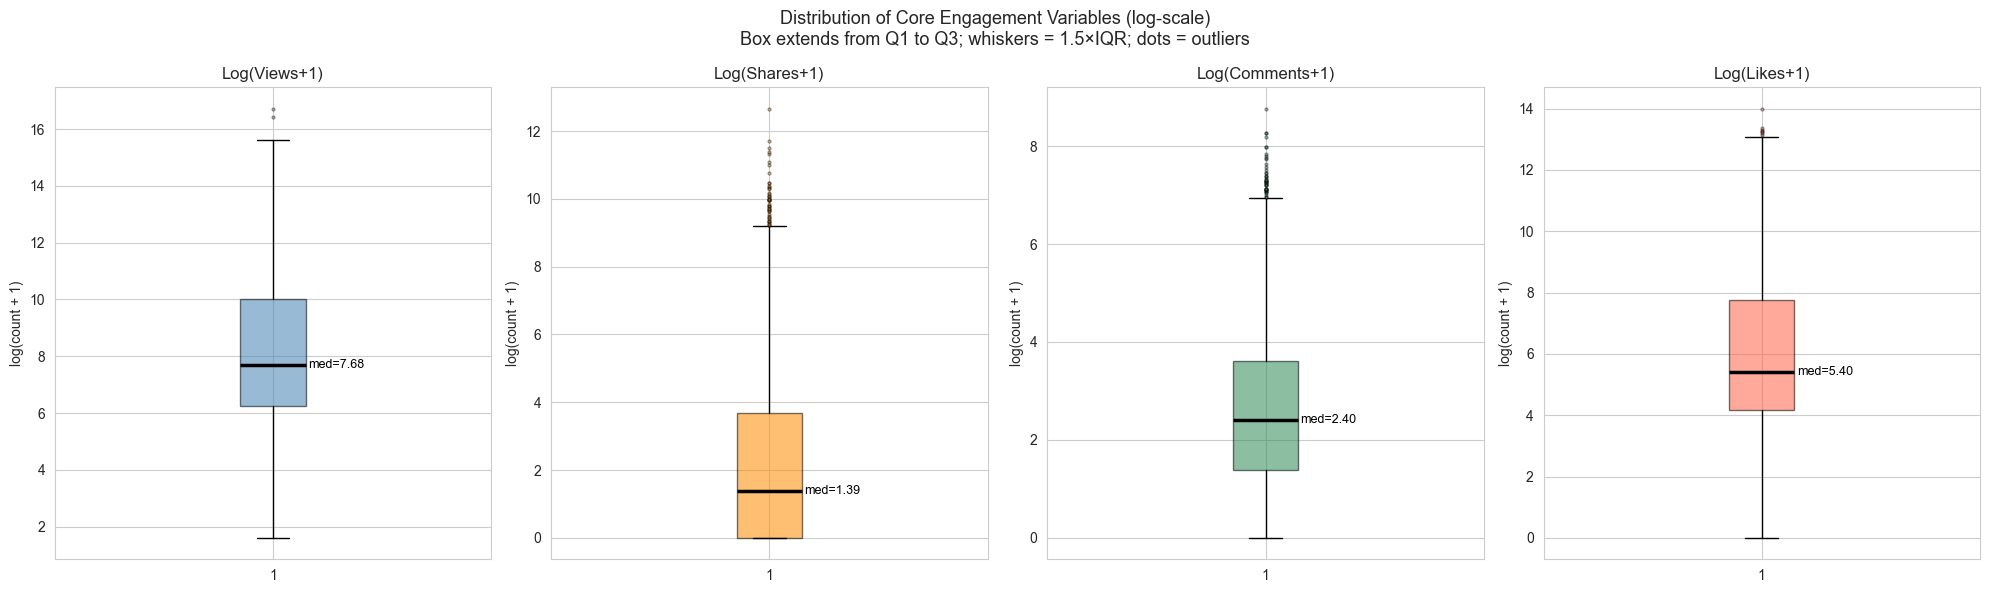

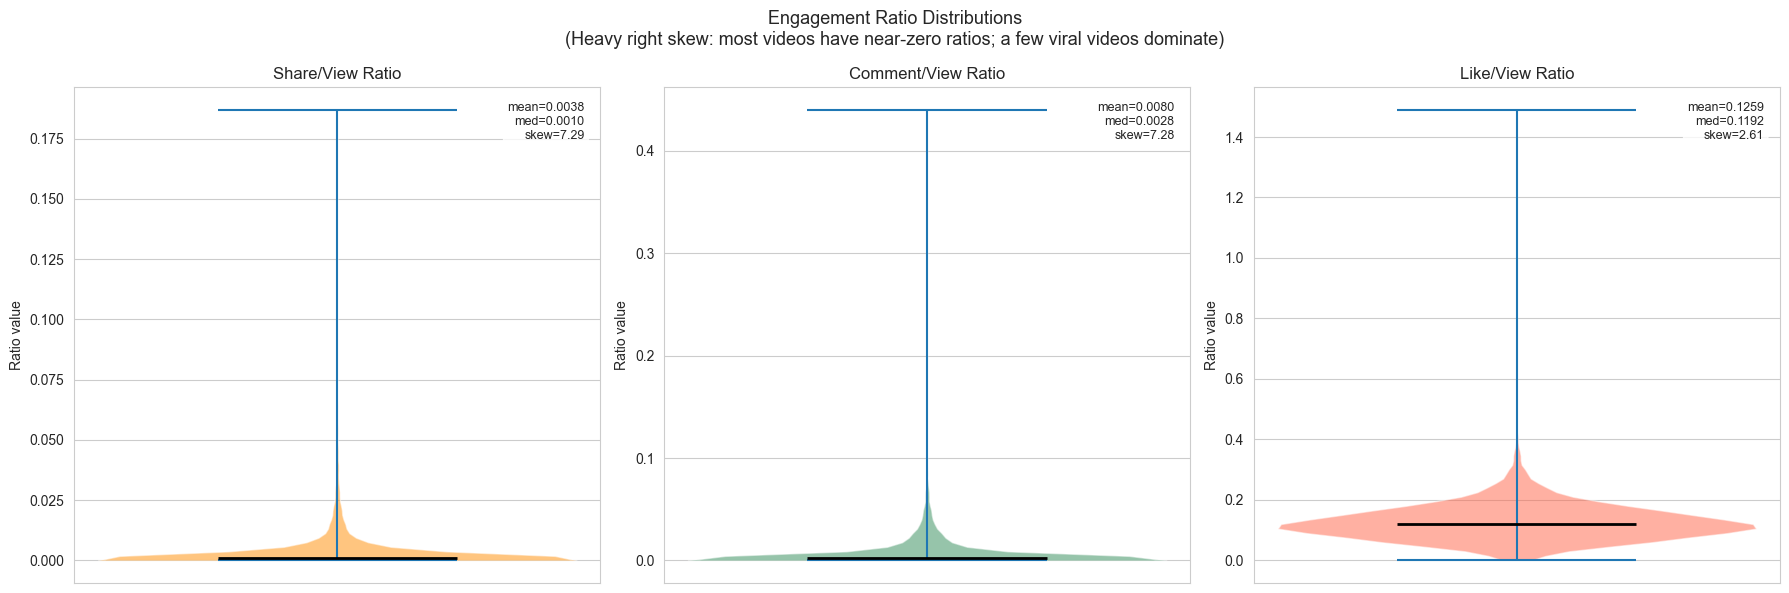

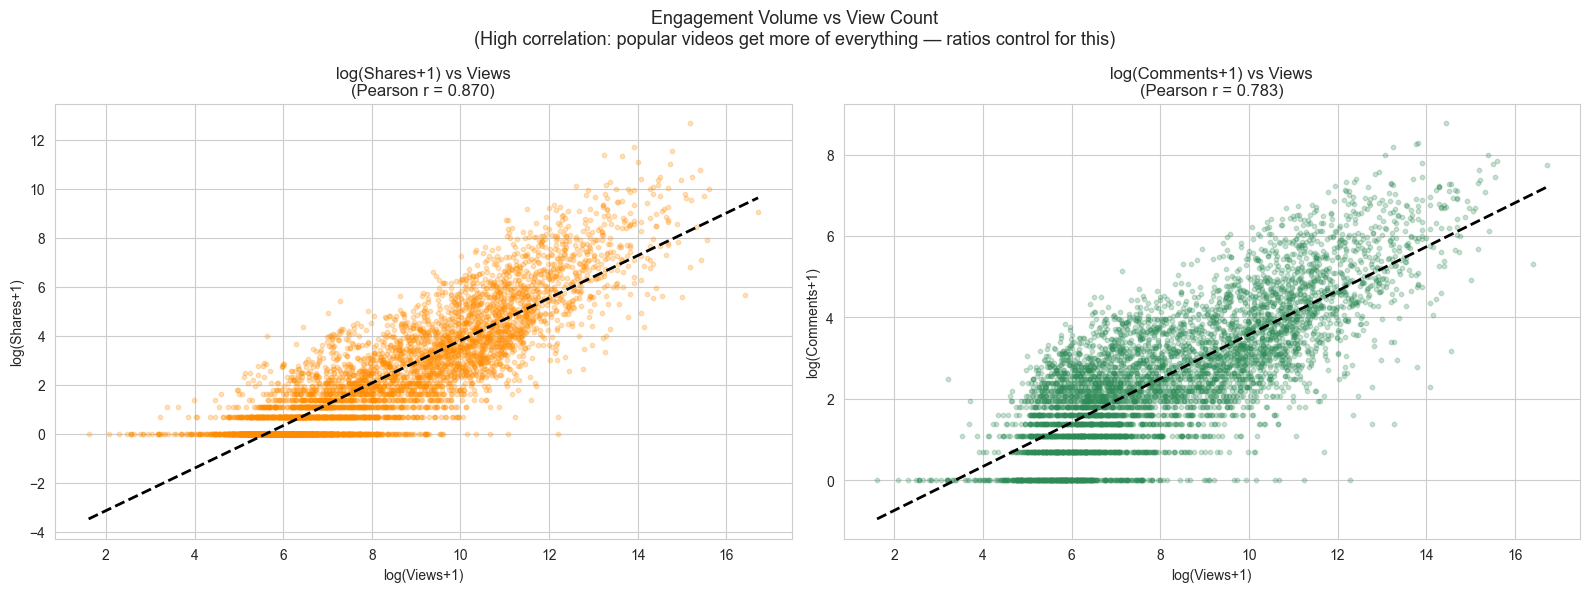

In [12]:
# ── Section 3A: Detailed EDA – Share, Comment, Like ─────────────────────────
# Per teacher feedback: dig into the three engagement variables before modelling

# ── 3A-1: Descriptive statistics ──────────────────────────────────────────────
eng_cols = ["views", "shares", "comments", "likes"]
print("=== Raw Engagement Counts ===")
print(df[eng_cols].describe().round(1).to_string())

print("\n=== Zero-count videos ===")
for c in ["shares", "comments", "likes"]:
    n_zero = (df[c] == 0).sum()
    pct    = n_zero / len(df) * 100
    print(f"  {c:12s}: {n_zero:5d} ({pct:.1f}%) have zero {c}")

print("\n=== Engagement Ratio Summary ===")
ratio_cols = ["share_view_ratio", "comment_view_ratio", "like_view_ratio"]
print(df[ratio_cols].describe().round(4).to_string())

# ── 3A-2: Box plots – raw counts (log-transformed for readability) ─────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
colors = ["steelblue", "darkorange", "seagreen", "tomato"]
labels = ["Views",     "Shares",     "Comments",  "Likes"]

for ax, col, color, label in zip(axes, ["log_views","log_shares","log_comments","log_likes"],
                                   colors, labels):
    data = df[col].dropna()
    bp   = ax.boxplot(data, vert=True, patch_artist=True,
                      boxprops=dict(facecolor=color, alpha=0.55),
                      medianprops=dict(color="black", linewidth=2.5),
                      flierprops=dict(marker="o", markersize=2,
                                      markerfacecolor=color, alpha=0.4))
    ax.set_title(f"Log({label}+1)", fontsize=12)
    ax.set_ylabel("log(count + 1)")
    # Annotate median
    median_val = data.median()
    ax.text(1.08, median_val, f"med={median_val:.2f}",
            va="center", fontsize=9, color="black")

plt.suptitle("Distribution of Core Engagement Variables (log-scale)\n"
             "Box extends from Q1 to Q3; whiskers = 1.5×IQR; dots = outliers",
             fontsize=13)
plt.tight_layout()
plt.show()

# ── 3A-3: Violin plots – engagement ratios ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ratio_info = [
    ("share_view_ratio",   "Share/View Ratio",   "darkorange"),
    ("comment_view_ratio", "Comment/View Ratio", "seagreen"),
    ("like_view_ratio",    "Like/View Ratio",    "tomato"),
]

for ax, (col, title, color) in zip(axes, ratio_info):
    data = df[col].dropna()
    parts = ax.violinplot(data, showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Ratio value")
    ax.set_xticks([])
    # Annotate key stats
    ax.text(0.97, 0.97,
            f"mean={data.mean():.4f}\nmed={data.median():.4f}\nskew={data.skew():.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Engagement Ratio Distributions\n"
             "(Heavy right skew: most videos have near-zero ratios; "
             "a few viral videos dominate)",
             fontsize=13)
plt.tight_layout()
plt.show()

# ── 3A-4: Scatter — shares vs views, comments vs views ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (x_col, y_col, y_label, color) in zip(axes, [
    ("log_views", "log_shares",   "log(Shares+1)",   "darkorange"),
    ("log_views", "log_comments", "log(Comments+1)", "seagreen"),
]):
    mask = df[[x_col, y_col]].notna().all(axis=1)
    ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
               alpha=0.25, s=10, color=color)
    r = df.loc[mask, [x_col, y_col]].corr().iloc[0, 1]
    z = np.polyfit(df.loc[mask, x_col], df.loc[mask, y_col], 1)
    x_rng = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_rng, np.poly1d(z)(x_rng), "k--", linewidth=2)
    ax.set_xlabel("log(Views+1)")
    ax.set_ylabel(y_label)
    ax.set_title(f"{y_label} vs Views\n(Pearson r = {r:.3f})")

plt.suptitle("Engagement Volume vs View Count\n"
             "(High correlation: popular videos get more of everything — "
             "ratios control for this)", fontsize=13)
plt.tight_layout()
plt.show()

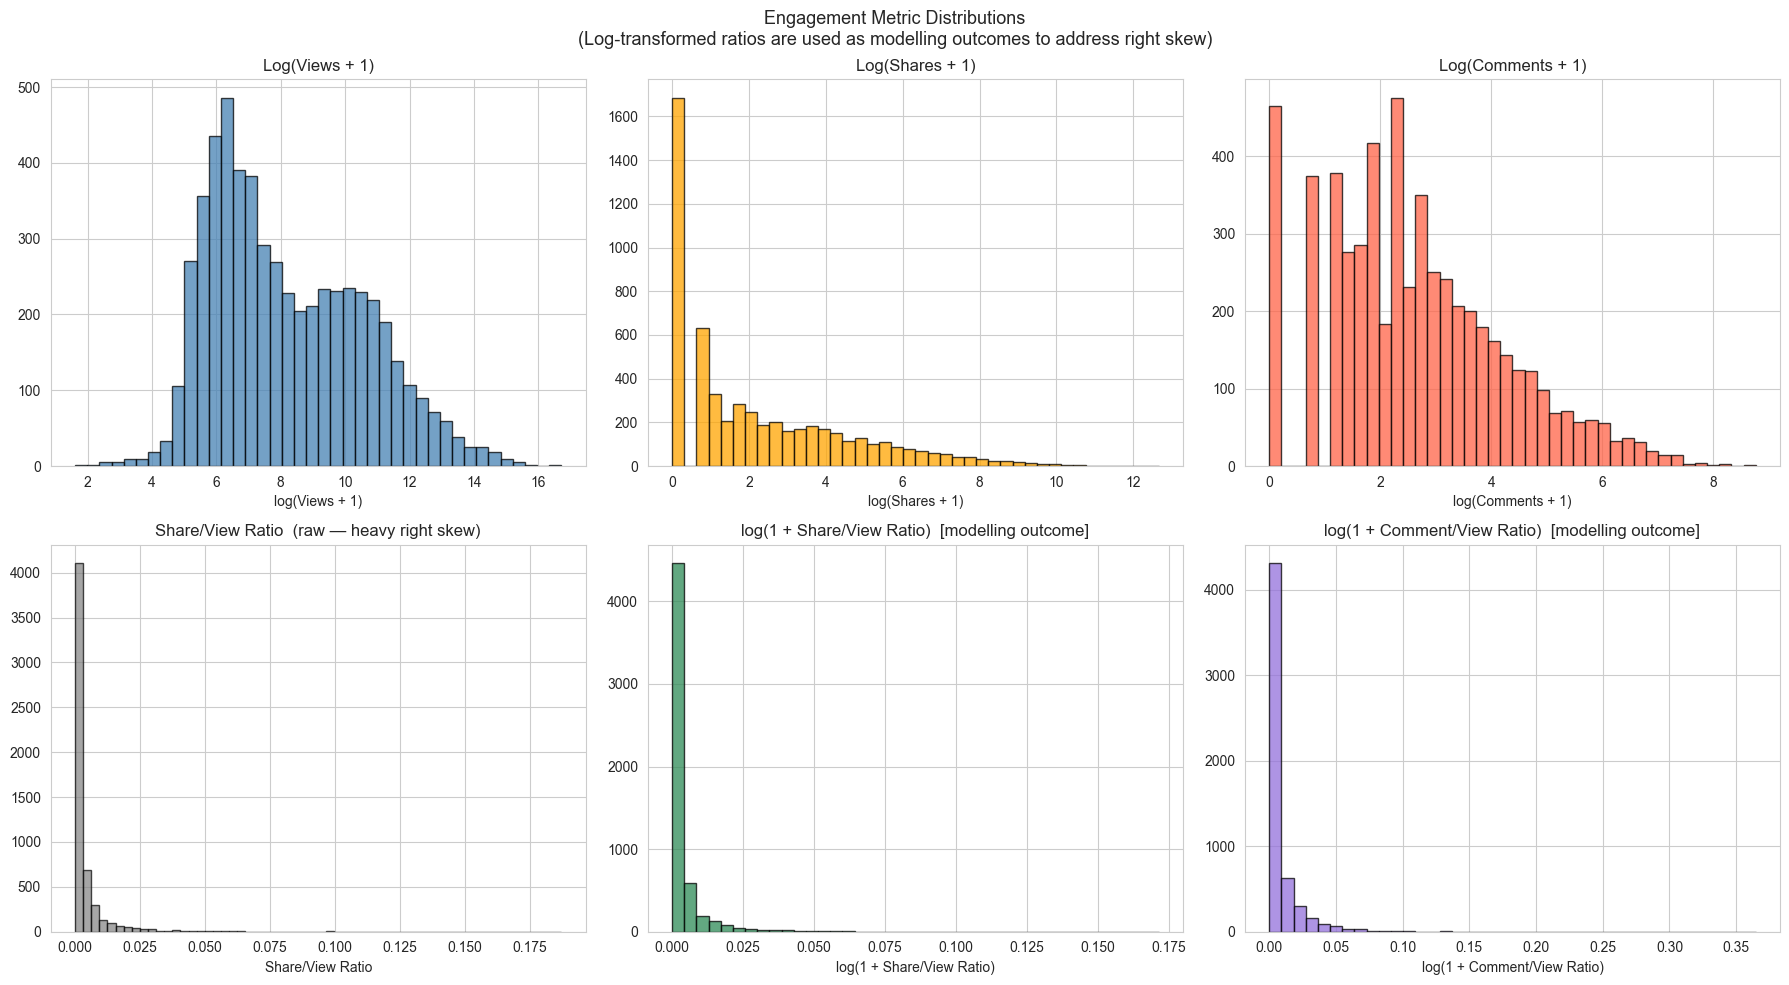

Skewness comparison:
  share_view_ratio         : raw=7.29  |  log=6.86
  comment_view_ratio       : raw=7.28  |  log=5.85


In [13]:
# Engagement metric distributions: raw vs log-transformed ratios
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: absolute counts (log-scale)
axes[0, 0].hist(df["log_views"],  bins=40, edgecolor="black", alpha=0.75, color="steelblue")
axes[0, 0].set_title("Log(Views + 1)")
axes[0, 0].set_xlabel("log(Views + 1)")

axes[0, 1].hist(df["log_shares"], bins=40, edgecolor="black", alpha=0.75, color="orange")
axes[0, 1].set_title("Log(Shares + 1)")
axes[0, 1].set_xlabel("log(Shares + 1)")

axes[0, 2].hist(df["log_comments"], bins=40, edgecolor="black", alpha=0.75, color="tomato")
axes[0, 2].set_title("Log(Comments + 1)")
axes[0, 2].set_xlabel("log(Comments + 1)")

# Row 2: engagement ratios — raw vs log-transformed (modelling outcomes)
axes[1, 0].hist(df["share_view_ratio"],  bins=60, edgecolor="black", alpha=0.7, color="gray")
axes[1, 0].set_title("Share/View Ratio  (raw — heavy right skew)")
axes[1, 0].set_xlabel("Share/View Ratio")

axes[1, 1].hist(df["log_share_view_ratio"],   bins=40, edgecolor="black", alpha=0.75, color="seagreen")
axes[1, 1].set_title("log(1 + Share/View Ratio)  [modelling outcome]")
axes[1, 1].set_xlabel("log(1 + Share/View Ratio)")

axes[1, 2].hist(df["log_comment_view_ratio"], bins=40, edgecolor="black", alpha=0.75, color="mediumpurple")
axes[1, 2].set_title("log(1 + Comment/View Ratio)  [modelling outcome]")
axes[1, 2].set_xlabel("log(1 + Comment/View Ratio)")

plt.suptitle(
    "Engagement Metric Distributions\n"
    "(Log-transformed ratios are used as modelling outcomes to address right skew)",
    fontsize=13)
plt.tight_layout()
plt.show()

# Print skewness before / after transformation
print("Skewness comparison:")
for col, log_col in [("share_view_ratio",   "log_share_view_ratio"),
                     ("comment_view_ratio",  "log_comment_view_ratio")]:
    print(f"  {col:25s}: raw={df[col].skew():.2f}  |  log={df[log_col].skew():.2f}")


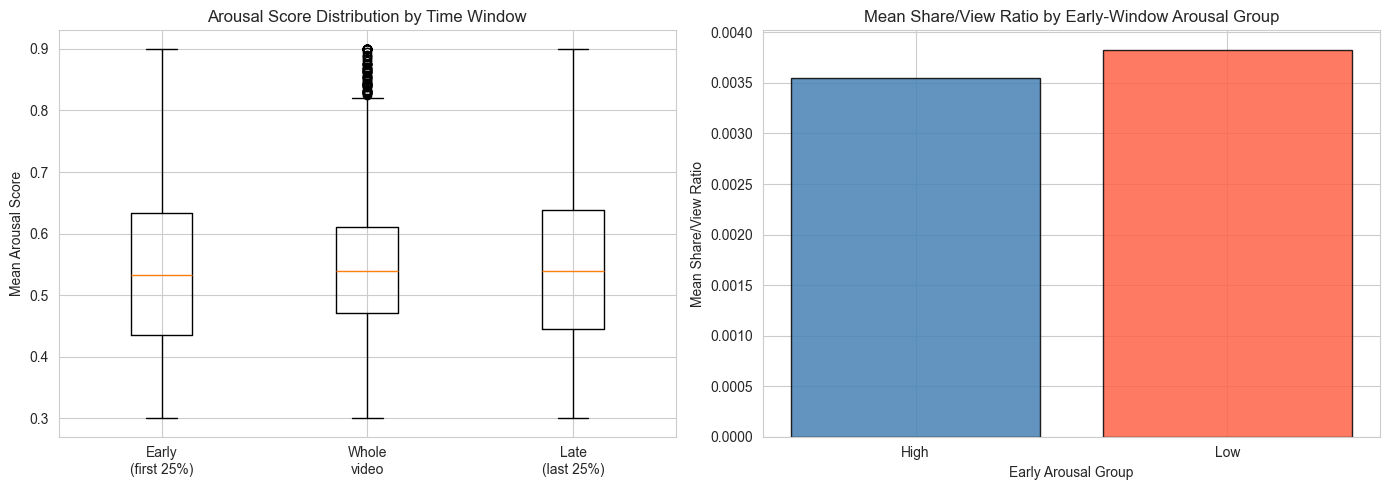


Correlation between window arousal scores:
               early_arousal  whole_arousal  late_arousal
early_arousal          1.000          0.761         0.388
whole_arousal          0.761          1.000         0.761
late_arousal           0.388          0.761         1.000


In [14]:
# Arousal distribution across the three time windows
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: per-window arousal distributions
arousal_data = [df["early_arousal"], df["whole_arousal"], df["late_arousal"]]
axes[0].boxplot(arousal_data,
                labels=["Early\n(first 25%)", "Whole\nvideo", "Late\n(last 25%)"])
axes[0].set_title("Arousal Score Distribution by Time Window")
axes[0].set_ylabel("Mean Arousal Score")

# Mean share/view ratio by early-window arousal group
grp = df.groupby("early_arousal_group")["share_view_ratio"].mean()
axes[1].bar(grp.index, grp.values,
            color=["steelblue", "tomato"], alpha=0.85, edgecolor="black")
axes[1].set_title("Mean Share/View Ratio by Early-Window Arousal Group")
axes[1].set_ylabel("Mean Share/View Ratio")
axes[1].set_xlabel("Early Arousal Group")

plt.tight_layout()
plt.show()

# Cross-window arousal correlation
print("\nCorrelation between window arousal scores:")
print(df[["early_arousal", "whole_arousal", "late_arousal"]].corr().round(3))


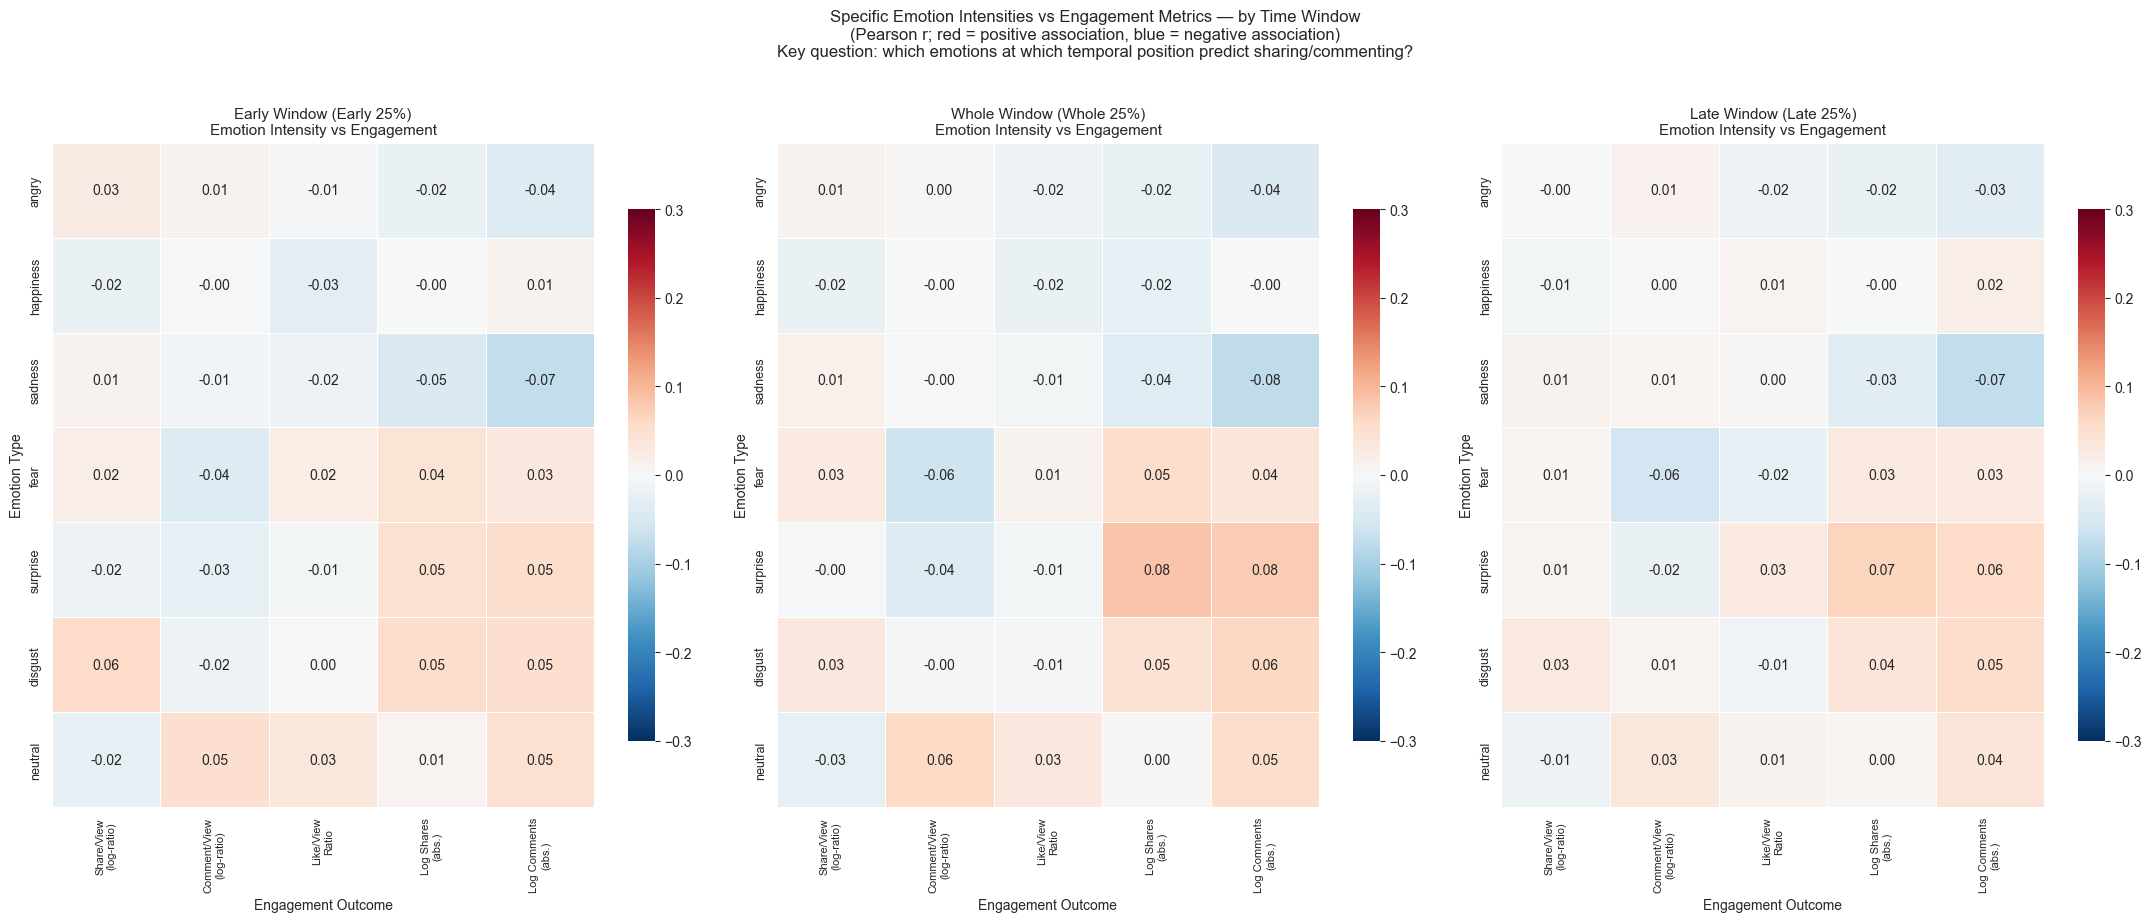

STRONGEST EMOTION–ENGAGEMENT ASSOCIATIONS (|r| > 0.05)

  [EARLY window]
    sadness      → Log Comments (abs.)             r=-0.074  (↓ less engagement)
    disgust      → Share/View (log-ratio)          r=+0.056  (↑ more engagement)
    disgust      → Log Shares (abs.)               r=+0.052  (↑ more engagement)
    surprise     → Log Comments (abs.)             r=+0.052  (↑ more engagement)
    disgust      → Log Comments (abs.)             r=+0.051  (↑ more engagement)
    neutral      → Comment/View (log-ratio)        r=+0.051  (↑ more engagement)

  [WHOLE window]
    surprise     → Log Shares (abs.)               r=+0.085  (↑ more engagement)
    surprise     → Log Comments (abs.)             r=+0.076  (↑ more engagement)
    sadness      → Log Comments (abs.)             r=-0.076  (↓ less engagement)
    disgust      → Log Comments (abs.)             r=+0.063  (↑ more engagement)
    fear         → Comment/View (log-ratio)        r=-0.062  (↓ less engagement)
    neutral      →

In [15]:
# ── Section 3B: Specific Emotion × Engagement Heatmaps ──────────────────────
# Per teacher feedback: arousal alone is insufficient — show individual emotions.
# This directly addresses: which specific emotions predict sharing / commenting?

EMOTION_NAMES = ["angry", "happiness", "sadness", "fear",
                 "surprise", "disgust", "neutral"]
OUTCOME_VARS  = ["log_share_view_ratio", "log_comment_view_ratio", "like_view_ratio",
                 "log_shares", "log_comments"]
OUTCOME_SHORT = {
    "log_share_view_ratio":   "Share/View\n(log-ratio)",
    "log_comment_view_ratio": "Comment/View\n(log-ratio)",
    "like_view_ratio":        "Like/View\nRatio",
    "log_shares":             "Log Shares\n(abs.)",
    "log_comments":           "Log Comments\n(abs.)",
}

fig, axes = plt.subplots(1, 3, figsize=(22, 9))

for ax, window in zip(axes, WINDOWS):
    # Build feature list for this window's specific emotions
    emo_feats = [f"{window}_{e}_intensity" for e in EMOTION_NAMES]
    emo_feats = [c for c in emo_feats if c in df.columns]

    all_cols  = emo_feats + [o for o in OUTCOME_VARS if o in df.columns]
    corr_full = df[all_cols].corr()
    corr_sub  = corr_full.loc[emo_feats,
                               [o for o in OUTCOME_VARS if o in df.columns]]

    # Row labels: clean emotion names
    row_labels = [f.replace(f"{window}_", "").replace("_intensity", "")
                  for f in emo_feats]
    col_labels = [OUTCOME_SHORT[o] for o in corr_sub.columns]

    sns.heatmap(corr_sub,
                ax=ax, annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3,
                linewidths=0.5, cbar_kws={"shrink": 0.8},
                xticklabels=col_labels,
                yticklabels=row_labels)
    ax.set_title(f"{'Early' if window=='early' else 'Whole' if window=='whole' else 'Late'} "
                 f"Window ({window.capitalize()} 25%)\nEmotion Intensity vs Engagement",
                 fontsize=11)
    ax.set_xlabel("Engagement Outcome", fontsize=10)
    ax.set_ylabel("Emotion Type", fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle(
    "Specific Emotion Intensities vs Engagement Metrics — by Time Window\n"
    "(Pearson r; red = positive association, blue = negative association)\n"
    "Key question: which emotions at which temporal position predict sharing/commenting?",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Text summary: strongest emotion–engagement links ─────────────────────────
print("=" * 70)
print("STRONGEST EMOTION–ENGAGEMENT ASSOCIATIONS (|r| > 0.05)")
print("=" * 70)

for window in WINDOWS:
    emo_feats = [f"{window}_{e}_intensity" for e in EMOTION_NAMES
                 if f"{window}_{e}_intensity" in df.columns]
    out_feats = [o for o in OUTCOME_VARS if o in df.columns]
    corr_sub  = df[emo_feats + out_feats].corr().loc[emo_feats, out_feats]

    print(f"\n  [{window.upper()} window]")
    rows = []
    for feat in emo_feats:
        for out in out_feats:
            r = corr_sub.loc[feat, out]
            if abs(r) > 0.05:
                emo  = feat.replace(f"{window}_","").replace("_intensity","")
                rows.append((abs(r), r, emo, OUTCOME_SHORT[out].replace('\n',' ')))
    rows.sort(reverse=True)
    for _, r, emo, out in rows[:6]:
        direction = "↑ more" if r > 0 else "↓ less"
        print(f"    {emo:12s} → {out:30s}  r={r:+.3f}  ({direction} engagement)")

# ── Section 3B-ii: Audio Feature Correlations (EDA) ───────────────────────────
print("\n" + "=" * 70)
print("AUDIO FEATURE – ENGAGEMENT CORRELATIONS (Pearson r)")
print("=" * 70)

audio_eda_outcomes = ["log_shares", "log_comments", "log_share_view_ratio", "log_comment_view_ratio"]
audio_feats_list = [c for c in audio_df.columns if c != "video_id" and c in df.columns]

for out in audio_eda_outcomes:
    if out not in df.columns:
        continue
    print(f"\n  [{out}]")
    pairs = []
    for af in audio_feats_list:
        r = df[[af, out]].corr().iloc[0, 1]
        pairs.append((abs(r), r, af))
    pairs.sort(reverse=True)
    for _, r, af in pairs:
        flag = " ★" if abs(r) > 0.05 else ""
        print(f"    {af:<35s}  r={r:+.4f}{flag}")

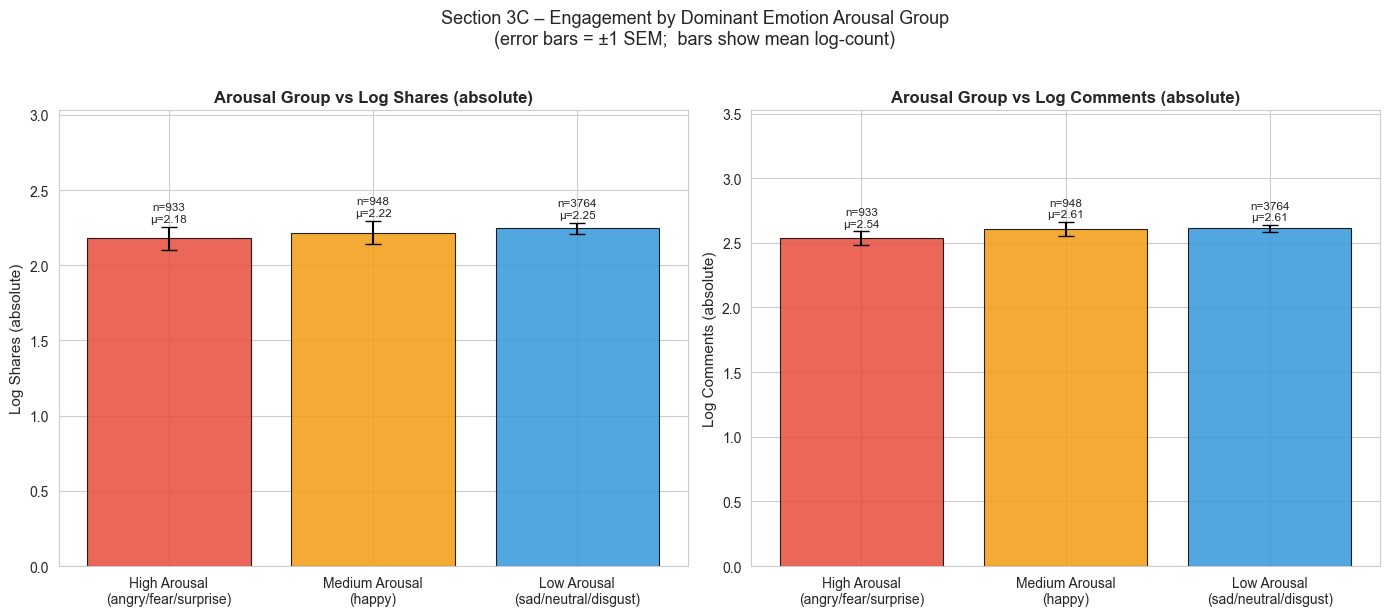


=== One-way ANOVA: Arousal Group × Log Shares ===
  F = 0.306,  p = 0.7365  (not significant)

=== One-way ANOVA: Arousal Group × Log Comments ===
  F = 0.766,  p = 0.4651  (not significant)

=== Post-hoc: High vs Low Arousal ===
  Shares  — High vs Low: Δμ=-0.066, t=-0.765, p=0.4442
  Comments — High vs Low: Δμ=-0.073, t=-1.240, p=0.2151


In [16]:
# ── Section 3C: High-Arousal vs Low-Arousal Group Comparison ─────────────────
# Teacher finding: high-arousal videos (angry/fear/surprise) show lower comment
# rate but higher share rate. This cell tests that directly.

HIGH_AROUSAL_EMOS = {"angry", "fear", "surprise"}
LOW_AROUSAL_EMOS  = {"sad", "neutral", "disgust"}

def arousal_group(emotion):
    if emotion in HIGH_AROUSAL_EMOS:
        return "High Arousal\n(angry/fear/surprise)"
    elif emotion in LOW_AROUSAL_EMOS:
        return "Low Arousal\n(sad/neutral/disgust)"
    else:
        return "Medium Arousal\n(happy)"

df["arousal_group_label"] = df["dominant_emotion"].apply(arousal_group)

group_order = [
    "High Arousal\n(angry/fear/surprise)",
    "Medium Arousal\n(happy)",
    "Low Arousal\n(sad/neutral/disgust)",
]
group_colors = {
    "High Arousal\n(angry/fear/surprise)": "#e74c3c",
    "Medium Arousal\n(happy)":             "#f39c12",
    "Low Arousal\n(sad/neutral/disgust)":  "#3498db",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, outcome, label in zip(
    axes,
    ["log_shares", "log_comments"],
    ["Log Shares (absolute)", "Log Comments (absolute)"],
):
    means = df.groupby("arousal_group_label")[outcome].mean().reindex(group_order)
    sems  = df.groupby("arousal_group_label")[outcome].sem().reindex(group_order)
    ns    = df.groupby("arousal_group_label")[outcome].count().reindex(group_order)

    bars = ax.bar(
        range(len(group_order)), means.values,
        yerr=sems.values, capsize=6,
        color=[group_colors[g] for g in group_order],
        edgecolor="black", alpha=0.85, linewidth=0.8,
    )
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order, fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f"Arousal Group vs {label}", fontsize=12, fontweight="bold")

    # Annotate bars with n and mean
    for bar, mean_val, n in zip(bars, means.values, ns.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + sems[group_order[list(bars).index(bar)]] + 0.02,
            f"n={int(n)}\nμ={mean_val:.2f}",
            ha="center", va="bottom", fontsize=8.5,
        )
    ax.set_ylim(0, means.max() * 1.35)

plt.suptitle(
    "Section 3C – Engagement by Dominant Emotion Arousal Group\n"
    "(error bars = ±1 SEM;  bars show mean log-count)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Statistical test: one-way ANOVA ─────────────────────────────────────────
from scipy.stats import f_oneway, ttest_ind

print("\n=== One-way ANOVA: Arousal Group × Log Shares ===")
groups_shares = [
    df[df["arousal_group_label"] == g]["log_shares"].dropna().values
    for g in group_order
]
f_stat, p_val = f_oneway(*groups_shares)
print(f"  F = {f_stat:.3f},  p = {p_val:.4f}  ({'significant' if p_val < 0.05 else 'not significant'})")

print("\n=== One-way ANOVA: Arousal Group × Log Comments ===")
groups_comments = [
    df[df["arousal_group_label"] == g]["log_comments"].dropna().values
    for g in group_order
]
f_stat2, p_val2 = f_oneway(*groups_comments)
print(f"  F = {f_stat2:.3f},  p = {p_val2:.4f}  ({'significant' if p_val2 < 0.05 else 'not significant'})")

print("\n=== Post-hoc: High vs Low Arousal ===")
hi_shares = df[df["arousal_group_label"] == "High Arousal\n(angry/fear/surprise)"]["log_shares"].dropna()
lo_shares = df[df["arousal_group_label"] == "Low Arousal\n(sad/neutral/disgust)"]["log_shares"].dropna()
t, p = ttest_ind(hi_shares, lo_shares)
diff = hi_shares.mean() - lo_shares.mean()
print(f"  Shares  — High vs Low: Δμ={diff:+.3f}, t={t:.3f}, p={p:.4f}")

hi_comm = df[df["arousal_group_label"] == "High Arousal\n(angry/fear/surprise)"]["log_comments"].dropna()
lo_comm = df[df["arousal_group_label"] == "Low Arousal\n(sad/neutral/disgust)"]["log_comments"].dropna()
t2, p2 = ttest_ind(hi_comm, lo_comm)
diff2 = hi_comm.mean() - lo_comm.mean()
print(f"  Comments — High vs Low: Δμ={diff2:+.3f}, t={t2:.3f}, p={p2:.4f}")


## Section 4 – Machine Learning Models: Dual-Channel Joint Analysis

**Framework**: Two emotional cue channels → engagement behaviour

| Channel | Features | Theoretical role |
|---|---|---|
| 👁 **Visual** | 7 emotions × 3 temporal windows + 3 arousal (24 features) | Facial expressions encode discrete emotional signals at different points in the video |
| 👂 **Audio** | Tempo, energy, brightness, ZCR, chroma + temporal deltas (13 features) | Acoustic atmosphere shapes the emotional climate and arousal state of viewers |

**Joint model**: all 37 features trained together → feature importance heatmap reveals which channel and which specific cue drives sharing vs commenting.

| Sub-section | Content |
|---|---|
| **4A** | Joint model 5-fold CV R² |
| **4B** | Dual-channel importance heatmap (Visual emotion × window + Audio features) |
| **4C** | OLS betas for top features |
| **4D** | Joint vs per-window R² comparison |
| **4E** | Robustness check with ratio outcomes |


### Research Question

> **How do specific emotional cues at different temporal positions in a short-form video**
> **shape viewers' information processing — as reflected in sharing, commenting, and liking behaviour?**

This directly addresses the broader question of **how people get information from social
media video depending on emotional cues**: engagement behaviour (sharing = propagating
information; commenting = elaborating on it; liking = low-effort acknowledgment) serves
as a behavioural proxy for distinct stages of social information processing.

#### Two-level analytical framework

**Level 1 — Temporal position (which window?)**

| Window | Frames used | Theoretical account |
|---|---|---|
| **Early** (first 25 %) | Opening emotional hook | *First-Impression*: arousal at onset sustains attention |
| **Whole** (all frames) | Sustained emotional climate | *Average-Tone*: overall affective register drives evaluation |
| **Late** (last 25 %) | Closing emotional peak | *Recency*: post-viewing activation triggers sharing |

**Level 2 — Specific emotion type (which emotion?)**

Rather than aggregating into a single arousal score, each model uses all **7 discrete
emotion intensities** (angry, happy, sad, fear, surprise, disgust, neutral) plus derived
arousal and high/low-arousal composites. This allows us to ask:

> *Is it sadness, joy, or anger that drives sharing? And does it matter whether that
> emotion appears at the beginning or end of the video?*

This level of specificity is essential for connecting the findings to **information
processing theory**: different emotions engage different cognitive-motivational pathways
(e.g., anger → high arousal → impulsive sharing; sadness → reflective processing → commenting).

**Outcome variables** (log-transformed to correct heavy right skew):
- `log_share_view_ratio`   = log(1 + shares / views) — *information propagation*
- `log_comment_view_ratio` = log(1 + comments / views) — *elaborative processing*

**Models** (one per window × outcome):
1. **Linear Regression** — interpretable baseline; OLS beta = direction and magnitude
2. **Random Forest** — captures non-linear emotion interactions
3. **Gradient Boosting** — high-capacity ensemble; feature importance = which emotions matter

**Evaluation**: 5-fold cross-validated R² and RMSE.


In [17]:
# ── Feature set construction ────────────────────────────────────────────────
# Visual channel: 7 emotions × 3 windows + 3 arousal = 24 features
def build_feature_set(window):
    cols = [f"{window}_arousal"] + EMOTION_COLS_BY_WINDOW[window]
    return [c for c in cols if c in df.columns]

FEATURE_SETS = {w: build_feature_set(w) for w in WINDOWS}

# ── Audio channel features ───────────────────────────────────────────────────
AUDIO_WHOLE_FEATURES = [
    "audio_tempo",          # rhythmic arousal (BPM)
    "audio_rms_energy",     # loudness / emotional intensity
    "audio_spec_centroid",  # spectral brightness → valence proxy
    "audio_zcr",            # roughness / speech presence
    "audio_chroma_std",     # harmonic complexity
]
AUDIO_TEMPORAL_FEATURES = [
    "early_audio_rms_energy",    "early_audio_spec_centroid",  "early_audio_zcr",
    "late_audio_rms_energy",     "late_audio_spec_centroid",   "late_audio_zcr",
    "audio_energy_delta",        "audio_brightness_delta",
]
AUDIO_FEATURES = AUDIO_WHOLE_FEATURES + AUDIO_TEMPORAL_FEATURES

# ── Joint feature set: Visual (24) + Audio (13) = 37 features ───────────────
VISUAL_FEATURES = []
for w in WINDOWS:
    VISUAL_FEATURES += FEATURE_SETS[w]
VISUAL_FEATURES = list(dict.fromkeys(VISUAL_FEATURES))

JOINT_FEATURES = VISUAL_FEATURES + [f for f in AUDIO_FEATURES if f in df.columns]

# ── Primary outcomes ─────────────────────────────────────────────────────────
OUTCOMES = ["log_shares", "log_comments"]
OUTCOME_LABELS = {
    "log_shares":   "Log Shares (absolute)",
    "log_comments": "Log Comments (absolute)",
}

# ── Control variables ────────────────────────────────────────────────────────
CONTROL_VARS = ["log_views"]

# ── Build modelling dataframe ────────────────────────────────────────────────
all_feat_cols = list(dict.fromkeys(JOINT_FEATURES))
df_model = df[all_feat_cols + OUTCOMES + CONTROL_VARS].dropna().copy()

print(f"Modelling dataset  : {len(df_model)} videos")
print(f"Visual features    : {len(VISUAL_FEATURES)}  (7 emotions × 3 windows + 3 arousal)")
print(f"Audio features     : {len([f for f in AUDIO_FEATURES if f in df.columns])}  (tempo, energy, brightness, ZCR, chroma + temporal)")
print(f"Total joint features: {len(JOINT_FEATURES)}")
print(f"Primary outcomes   : {OUTCOMES}")


Modelling dataset  : 5645 videos
Visual features    : 24  (7 emotions × 3 windows + 3 arousal)
Audio features     : 13  (tempo, energy, brightness, ZCR, chroma + temporal)
Total joint features: 37
Primary outcomes   : ['log_shares', 'log_comments']


In [18]:
# ── 5-fold cross-validated evaluation ───────────────────────────────────────
CV = KFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    "LinearRegression": LinearRegression(),
    "RandomForest":     RandomForestRegressor(n_estimators=200, max_depth=8,
                                              random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                  learning_rate=0.05, random_state=42),
}

results = []   # list of dicts – one row per (outcome, window_or_joint, model)

print("=" * 75)
print(f"JOINT MODEL  –  all {len(JOINT_FEATURES)} features (24 visual + 13 audio) together (primary)")
print("=" * 75)
for outcome in OUTCOMES:
    y        = df_model[outcome].values
    X        = df_model[JOINT_FEATURES].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for model_name, model in MODELS.items():
        cv_r2      = cross_val_score(model, X_scaled, y, cv=CV,
                                     scoring="r2", n_jobs=-1)
        cv_neg_mse = cross_val_score(model, X_scaled, y, cv=CV,
                                     scoring="neg_mean_squared_error", n_jobs=-1)
        results.append({
            "outcome":      outcome,
            "window":       "joint",
            "model":        model_name,
            "cv_r2_mean":   cv_r2.mean(),
            "cv_r2_std":    cv_r2.std(),
            "cv_rmse_mean": np.sqrt(-cv_neg_mse.mean()),
            "cv_rmse_std":  np.sqrt(cv_neg_mse.std()),
        })
        print(f"[{outcome}] JOINT | {model_name:20s} "
              f"R²={cv_r2.mean():.4f}±{cv_r2.std():.4f}  "
              f"RMSE={np.sqrt(-cv_neg_mse.mean()):.4f}")

print()
print("=" * 75)
print("PER-WINDOW MODELS  –  robustness check (single-window features)")
print("=" * 75)
for outcome in OUTCOMES:
    y = df_model[outcome].values
    for window in WINDOWS:
        X        = df_model[FEATURE_SETS[window]].values
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        for model_name, model in MODELS.items():
            cv_r2      = cross_val_score(model, X_scaled, y, cv=CV,
                                         scoring="r2", n_jobs=-1)
            cv_neg_mse = cross_val_score(model, X_scaled, y, cv=CV,
                                         scoring="neg_mean_squared_error", n_jobs=-1)
            results.append({
                "outcome":      outcome,
                "window":       window,
                "model":        model_name,
                "cv_r2_mean":   cv_r2.mean(),
                "cv_r2_std":    cv_r2.std(),
                "cv_rmse_mean": np.sqrt(-cv_neg_mse.mean()),
                "cv_rmse_std":  np.sqrt(cv_neg_mse.std()),
            })
            print(f"[{outcome}] {window:5s} | {model_name:20s} "
                  f"R²={cv_r2.mean():.4f}±{cv_r2.std():.4f}")

results_df = pd.DataFrame(results)
print(f"\nCross-validation complete.  Total runs: {len(results_df)}")


JOINT MODEL  –  all 37 features (24 visual + 13 audio) together (primary)
[log_shares] JOINT | LinearRegression     R²=0.0360±0.0038  RMSE=2.3182
[log_shares] JOINT | RandomForest         R²=0.0829±0.0046  RMSE=2.2611
[log_shares] JOINT | GradientBoosting     R²=0.0816±0.0102  RMSE=2.2628
[log_comments] JOINT | LinearRegression     R²=0.0246±0.0122  RMSE=1.6096
[log_comments] JOINT | RandomForest         R²=0.0748±0.0148  RMSE=1.5678
[log_comments] JOINT | GradientBoosting     R²=0.0688±0.0119  RMSE=1.5729

PER-WINDOW MODELS  –  robustness check (single-window features)
[log_shares] early | LinearRegression     R²=0.0044±0.0029
[log_shares] early | RandomForest         R²=0.0304±0.0078
[log_shares] early | GradientBoosting     R²=0.0159±0.0069
[log_shares] whole | LinearRegression     R²=0.0078±0.0016
[log_shares] whole | RandomForest         R²=0.0452±0.0104
[log_shares] whole | GradientBoosting     R²=0.0343±0.0124
[log_shares] late  | LinearRegression     R²=0.0030±0.0073
[log_share

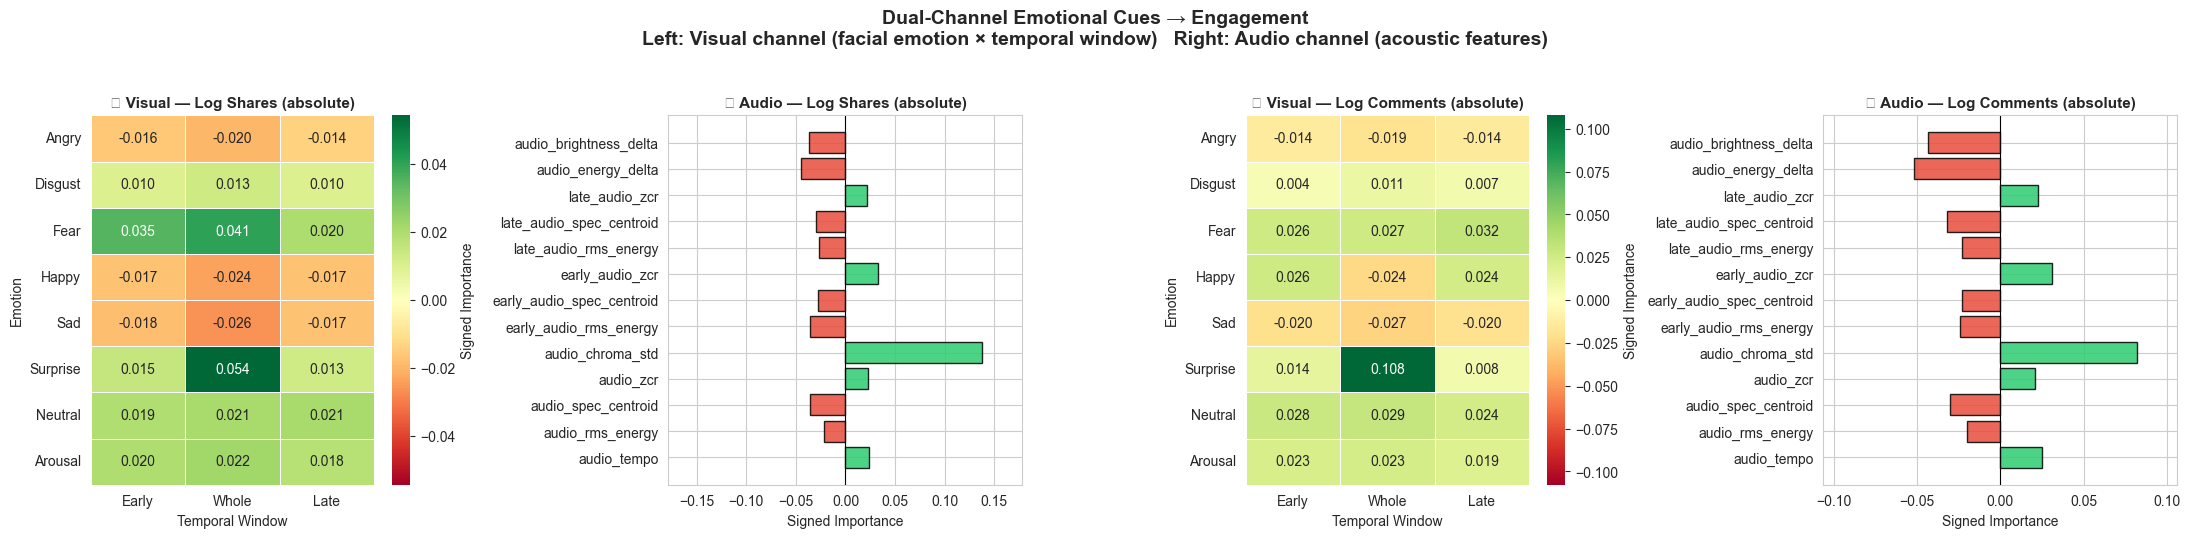


=== TOP DRIVERS BY CHANNEL ===

Outcome: Log Shares (absolute)
  👁 Visual top 5:
    ↑ Surprise     @ Whole    (+0.0543)
    ↑ Fear         @ Whole    (+0.0406)
    ↑ Fear         @ Early    (+0.0349)
    ↓ Sad          @ Whole    (-0.0260)
    ↓ Happy        @ Whole    (-0.0237)
  👂 Audio top 5:
    ↑ audio_chroma_std                     (+0.1374)
    ↓ audio_energy_delta                   (-0.0444)
    ↓ audio_brightness_delta               (-0.0371)
    ↓ early_audio_rms_energy               (-0.0360)
    ↓ audio_spec_centroid                  (-0.0359)

Outcome: Log Comments (absolute)
  👁 Visual top 5:
    ↑ Surprise     @ Whole    (+0.1077)
    ↑ Fear         @ Late     (+0.0318)
    ↑ Neutral      @ Whole    (+0.0295)
    ↑ Neutral      @ Early    (+0.0282)
    ↑ Fear         @ Whole    (+0.0267)
  👂 Audio top 5:
    ↑ audio_chroma_std                     (+0.0818)
    ↓ audio_energy_delta                   (-0.0517)
    ↓ audio_brightness_delta               (-0.0437)
    ↓ la

In [19]:
# ── Section 4B: Dual-Channel Feature Importance Heatmap ────────────────────
# Train ONE RF on all 37 features (visual + audio).
# Visualise as TWO panels:
#   Left  → Visual channel:  Emotion × Temporal Window (8 rows × 3 cols)
#   Right → Audio channel:   Feature × Outcome (bar chart with direction)
# Direction is inferred from Pearson correlation sign.

EMOTION_BASE_NAMES = [
    "angry_intensity", "disgust_intensity", "fear_intensity",
    "happiness_intensity", "sadness_intensity", "surprise_intensity",
    "neutral_intensity", "arousal",
]
EMOTION_DISPLAY = {
    "angry_intensity":    "Angry",
    "disgust_intensity":  "Disgust",
    "fear_intensity":     "Fear",
    "happiness_intensity":"Happy",
    "sadness_intensity":  "Sad",
    "surprise_intensity": "Surprise",
    "neutral_intensity":  "Neutral",
    "arousal":            "Arousal",
}

importance_summary   = {}    # visual heatmap matrices
audio_importance_df  = {}    # audio bar chart data

for outcome in OUTCOMES:
    y = df_model[outcome].values
    X_sc = StandardScaler().fit_transform(df_model[JOINT_FEATURES].values)

    rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                               random_state=42, n_jobs=-1)
    rf.fit(X_sc, y)

    imp_d  = dict(zip(JOINT_FEATURES, rf.feature_importances_))
    corr_d = {f: np.corrcoef(df_model[f].values, y)[0, 1] for f in JOINT_FEATURES}

    # ── Visual importance matrix ────────────────────────────────────────────
    matrix = np.zeros((len(EMOTION_BASE_NAMES), len(WINDOWS)))
    for ei, emo in enumerate(EMOTION_BASE_NAMES):
        for wi, win in enumerate(WINDOWS):
            feat = f"{win}_{emo}"
            matrix[ei, wi] = imp_d.get(feat, 0) * np.sign(corr_d.get(feat, 0))

    rows_e = [EMOTION_DISPLAY[e] for e in EMOTION_BASE_NAMES]
    cols_w = [w.capitalize() for w in WINDOWS]
    importance_summary[outcome] = pd.DataFrame(matrix, index=rows_e, columns=cols_w)

    # ── Audio importance series ─────────────────────────────────────────────
    audio_imps = {
        f: imp_d.get(f, 0) * np.sign(corr_d.get(f, 0))
        for f in AUDIO_FEATURES if f in JOINT_FEATURES
    }
    audio_importance_df[outcome] = audio_imps

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 9))
fig.suptitle(
    "Dual-Channel Emotional Cues → Engagement\n"
    "Left: Visual channel (facial emotion × temporal window)   "
    "Right: Audio channel (acoustic features)",
    fontsize=14, fontweight="bold", y=1.02,
)

for col_idx, outcome in enumerate(OUTCOMES):
    # — Visual heatmap —
    ax_vis = fig.add_subplot(2, 4, col_idx * 2 + 1)
    mat = importance_summary[outcome].values
    vmax = max(np.abs(mat).max(), 1e-6)
    sns.heatmap(
        mat, ax=ax_vis,
        xticklabels=cols_w, yticklabels=rows_e,
        cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt=".3f", linewidths=0.4,
        cbar_kws={"label": "Signed Importance"},
    )
    ax_vis.set_title(f"👁 Visual — {OUTCOME_LABELS[outcome]}", fontsize=11, fontweight="bold")
    ax_vis.set_xlabel("Temporal Window"); ax_vis.set_ylabel("Emotion")

    # — Audio bar chart —
    ax_aud = fig.add_subplot(2, 4, col_idx * 2 + 2)
    audio_d  = audio_importance_df[outcome]
    labels   = list(audio_d.keys())
    values   = list(audio_d.values())
    colors   = ["#2ecc71" if v >= 0 else "#e74c3c" for v in values]
    ax_aud.barh(labels, values, color=colors, edgecolor="black", alpha=0.85)
    ax_aud.axvline(0, color="black", linewidth=0.8)
    ax_aud.set_title(f"👂 Audio — {OUTCOME_LABELS[outcome]}", fontsize=11, fontweight="bold")
    ax_aud.set_xlabel("Signed Importance")
    ax_aud.set_xlim(-max(abs(v) for v in values)*1.3-1e-6,
                     max(abs(v) for v in values)*1.3+1e-6)

plt.tight_layout()
plt.show()

# ── Print top drivers per channel ────────────────────────────────────────────
print("\n=== TOP DRIVERS BY CHANNEL ===")
for outcome in OUTCOMES:
    print(f"\nOutcome: {OUTCOME_LABELS[outcome]}")

    # Visual top 5
    flat = importance_summary[outcome].stack().reset_index()
    flat.columns = ["Emotion", "Window", "SignedImp"]
    flat = flat.reindex(flat["SignedImp"].abs().sort_values(ascending=False).index)
    print("  👁 Visual top 5:")
    for _, row in flat.head(5).iterrows():
        d = "↑" if row["SignedImp"] > 0 else "↓"
        print(f"    {d} {row['Emotion']:12s} @ {row['Window']:7s}  ({row['SignedImp']:+.4f})")

    # Audio top 5
    audio_sorted = sorted(audio_importance_df[outcome].items(),
                          key=lambda x: abs(x[1]), reverse=True)
    print("  👂 Audio top 5:")
    for feat, imp in audio_sorted[:5]:
        d = "↑" if imp > 0 else "↓"
        print(f"    {d} {feat:<35s}  ({imp:+.4f})")


In [20]:
# ── Section 4C: OLS with Joint Features – Interpretable Beta Coefficients ────
# OLS on the top emotion × window predictors for clean interpretation.
# We select the 8 features with highest absolute signed importance per outcome.

SEP = "=" * 70
ols_results = {}

for outcome in OUTCOMES:
    y = df_model[outcome].values
    print(f"\n{SEP}")
    print(f"OLS (Joint Features) – Outcome: {OUTCOME_LABELS[outcome]}")
    print(SEP)

    # Pick top features by absolute signed importance (visual + audio)
    flat = importance_summary[outcome].stack().reset_index()
    flat.columns = ["Emotion", "Window", "SignedImportance"]
    flat["feature"] = flat["Window"].str.lower() + "_" + \
        flat["Emotion"].map({v: k for k, v in EMOTION_DISPLAY.items()})
    flat = flat.reindex(flat["SignedImportance"].abs().sort_values(ascending=False).index)
    top_visual = [f for f in flat["feature"].tolist() if f in df_model.columns][:7]

    audio_sorted = sorted(audio_importance_df[outcome].items(),
                          key=lambda x: abs(x[1]), reverse=True)
    top_audio = [f for f, _ in audio_sorted if f in df_model.columns][:3]
    top_feats = top_visual + top_audio

    X_ols = sm.add_constant(df_model[top_feats])
    ols_model = sm.OLS(y, X_ols).fit()
    ols_results[outcome] = ols_model

    print(f"  R²={ols_model.rsquared:.4f}  |  Adj R²={ols_model.rsquared_adj:.4f}"
          f"  |  F-p={ols_model.f_pvalue:.4e}")
    print(f"\n  {'Feature':<45s}  {'Beta':>10s}  {'p-value':>10s}  Sig")
    print("  " + "-" * 75)
    for param in top_feats:
        b   = ols_model.params.get(param, np.nan)
        p   = ols_model.pvalues.get(param, np.nan)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {param:<45s}  {b:+10.4f}  {p:10.4f}  {sig}")



OLS (Joint Features) – Outcome: Log Shares (absolute)
  R²=0.0236  |  Adj R²=0.0219  |  F-p=5.0525e-24

  Feature                                              Beta     p-value  Sig
  ---------------------------------------------------------------------------
  whole_surprise_intensity                          +3.3008      0.0000  ***
  whole_fear_intensity                              +0.9236      0.0273  *
  early_fear_intensity                              +0.0912      0.7190  
  whole_sadness_intensity                           -5.6177      0.0009  ***
  whole_happiness_intensity                         -1.8176      0.0026  **
  whole_arousal                                     -9.6815      0.0007  ***
  whole_neutral_intensity                           -5.5231      0.0011  **
  audio_chroma_std                                 +13.2573      0.0000  ***
  audio_energy_delta                                -2.5589      0.0015  **
  audio_brightness_delta                            -0.

In [21]:
# ── Section 4D: Joint vs Per-Window Model Comparison ────────────────────────
print("=" * 75)
print(f"MODEL COMPARISON: JOINT (all {len(JOINT_FEATURES)} features) vs PER-WINDOW (8 features each)")
print("=" * 75)

for outcome in OUTCOMES:
    label = OUTCOME_LABELS[outcome]
    print(f"\nOutcome: {label}")
    print(f"  {'Model':<22s}  {'Joint R²':>10s}  {'Early R²':>10s}  "
          f"{'Whole R²':>10s}  {'Late R²':>10s}")
    print("  " + "-" * 65)

    joint_sub = results_df[(results_df["outcome"] == outcome) &
                           (results_df["window"] == "joint")]
    for model_name in MODELS:
        j_r2 = joint_sub[joint_sub["model"] == model_name]["cv_r2_mean"].values
        j_r2 = j_r2[0] if len(j_r2) else np.nan

        window_r2s = {}
        for win in WINDOWS:
            sub = results_df[(results_df["outcome"] == outcome) &
                             (results_df["window"] == win) &
                             (results_df["model"] == model_name)]
            window_r2s[win] = sub["cv_r2_mean"].values[0] if len(sub) else np.nan

        best_win = max(window_r2s, key=window_r2s.get)
        indicator = "▲" if j_r2 >= max(window_r2s.values()) else " "
        print(f"  {model_name:<22s}  {j_r2:>+10.4f}  "
              f"{window_r2s['early']:>+10.4f}  "
              f"{window_r2s['whole']:>+10.4f}  "
              f"{window_r2s['late']:>+10.4f}  {indicator}")

print("\n  ▲ = joint model outperforms all single-window models")
print("\nInterpretation: joint model captures cross-window interactions")
print("that single-window models miss (e.g. fear early + neutral late).")


MODEL COMPARISON: JOINT (all 37 features) vs PER-WINDOW (8 features each)

Outcome: Log Shares (absolute)
  Model                     Joint R²    Early R²    Whole R²     Late R²
  -----------------------------------------------------------------
  LinearRegression           +0.0360     +0.0044     +0.0078     +0.0030  ▲
  RandomForest               +0.0829     +0.0304     +0.0452     +0.0189  ▲
  GradientBoosting           +0.0816     +0.0159     +0.0343     +0.0161  ▲

Outcome: Log Comments (absolute)
  Model                     Joint R²    Early R²    Whole R²     Late R²
  -----------------------------------------------------------------
  LinearRegression           +0.0246     +0.0079     +0.0114     +0.0061  ▲
  RandomForest               +0.0748     +0.0450     +0.0471     +0.0326  ▲
  GradientBoosting           +0.0688     +0.0398     +0.0382     +0.0310  ▲

  ▲ = joint model outperforms all single-window models

Interpretation: joint model captures cross-window interactions
th

### Section 4E – Ablation Study: Contribution of Each Sensory Channel

**Purpose**: Isolate the independent predictive contribution of each emotional cue channel
(visual facial emotion vs audio acoustic features) and quantify the gain from combining them.

This directly addresses the dual-coding theory question: do visual and audio emotional cues
provide **redundant** or **complementary** information for predicting engagement?

ABLATION STUDY – Channel Contribution

  Outcome: Log Shares (absolute)
  Channel                      LR R²       RF R²       GB R²
  ------------------------------------------------------------
  Visual only (24)        +0.0057±0.002  +0.0508±0.009  +0.0356±0.006
  Audio only (13)         +0.0328±0.004  +0.0744±0.012  +0.0640±0.014
  Joint (37)              +0.0360±0.004  +0.0829±0.005  +0.0816±0.010

  Outcome: Log Comments (absolute)
  Channel                      LR R²       RF R²       GB R²
  ------------------------------------------------------------
  Visual only (24)        +0.0084±0.012  +0.0587±0.017  +0.0386±0.021
  Audio only (13)         +0.0172±0.007  +0.0604±0.016  +0.0416±0.015
  Joint (37)              +0.0246±0.012  +0.0748±0.015  +0.0688±0.012

COMPLEMENTARITY ANALYSIS

  Log Shares (absolute) (RandomForest):
    Visual R²  = 0.0508
    Audio  R²  = 0.0744
    Additive   = 0.1252  (if channels were independent)
    Joint  R²  = 0.0829
    Synergy    = -0.0423  (re

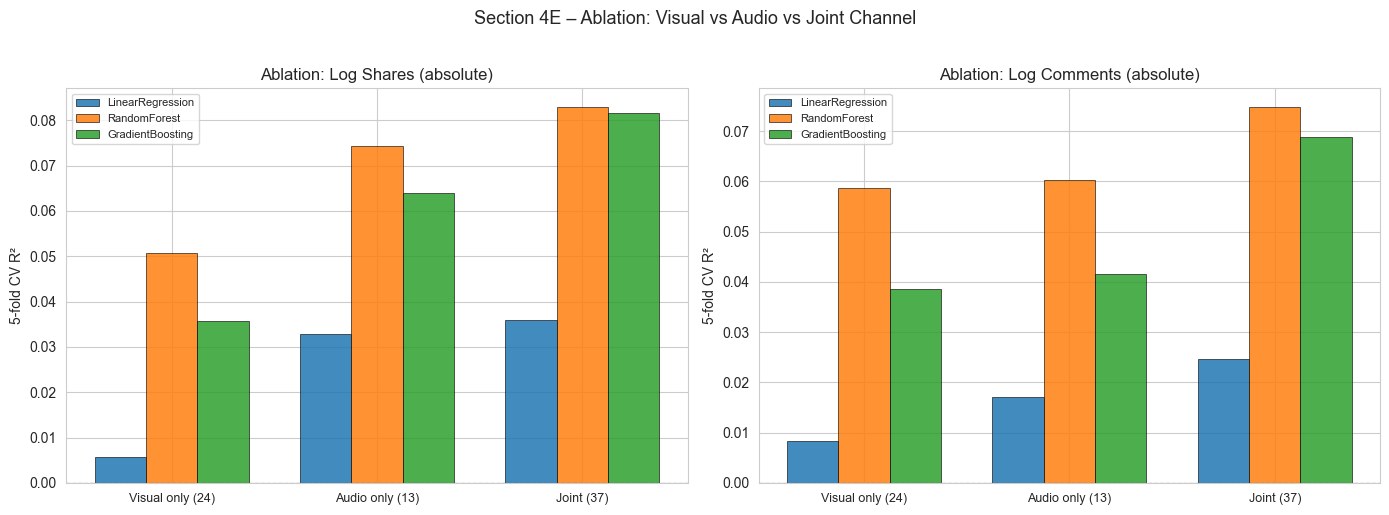

In [22]:
# ── Section 4E: Ablation Study ─────────────────────────────────────────────
# Compare: Visual-only (24) vs Audio-only (13) vs Joint (37)
# This quantifies whether the two sensory channels provide complementary info.

CHANNEL_SETS = {
    "Visual only (24)": VISUAL_FEATURES,
    "Audio only (13)":  [f for f in AUDIO_FEATURES if f in df_model.columns],
    "Joint (37)":       JOINT_FEATURES,
}

ablation_results = []

print("=" * 75)
print("ABLATION STUDY – Channel Contribution")
print("=" * 75)

for outcome in OUTCOMES:
    y = df_model[outcome].values
    print(f"\n  Outcome: {OUTCOME_LABELS[outcome]}")
    print(f"  {'Channel':<22s}  {'LR R²':>10s}  {'RF R²':>10s}  {'GB R²':>10s}")
    print("  " + "-" * 60)

    for ch_name, ch_feats in CHANNEL_SETS.items():
        X_sc = StandardScaler().fit_transform(df_model[ch_feats].values)
        row = {"outcome": outcome, "channel": ch_name}
        for m_name, m_obj in MODELS.items():
            cv = cross_val_score(m_obj, X_sc, y, cv=CV, scoring="r2", n_jobs=-1)
            row[f"{m_name}_r2"] = cv.mean()
            row[f"{m_name}_std"] = cv.std()
        ablation_results.append(row)
        print(f"  {ch_name:<22s}  "
              f"{row['LinearRegression_r2']:+.4f}±{row['LinearRegression_std']:.3f}  "
              f"{row['RandomForest_r2']:+.4f}±{row['RandomForest_std']:.3f}  "
              f"{row['GradientBoosting_r2']:+.4f}±{row['GradientBoosting_std']:.3f}")

ablation_df = pd.DataFrame(ablation_results)

# Compute complementarity
print(f"\n{'=' * 75}")
print("COMPLEMENTARITY ANALYSIS")
print("=" * 75)
for outcome in OUTCOMES:
    sub = ablation_df[ablation_df["outcome"] == outcome]
    vis_r2  = sub[sub["channel"].str.startswith("Visual")]["RandomForest_r2"].values[0]
    aud_r2  = sub[sub["channel"].str.startswith("Audio")]["RandomForest_r2"].values[0]
    joint_r2 = sub[sub["channel"].str.startswith("Joint")]["RandomForest_r2"].values[0]
    additive = vis_r2 + aud_r2
    synergy  = joint_r2 - additive

    print(f"\n  {OUTCOME_LABELS[outcome]} (RandomForest):")
    print(f"    Visual R²  = {vis_r2:.4f}")
    print(f"    Audio  R²  = {aud_r2:.4f}")
    print(f"    Additive   = {additive:.4f}  (if channels were independent)")
    print(f"    Joint  R²  = {joint_r2:.4f}")
    print(f"    Synergy    = {synergy:+.4f}  {'(complementary ✓)' if synergy > 0 else '(redundant)'}")

# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ch_colors = {"Visual only (24)": "#3498db", "Audio only (13)": "#e67e22",
             "Joint (37)": "#8e44ad"}

for ax_idx, outcome in enumerate(OUTCOMES):
    sub = ablation_df[ablation_df["outcome"] == outcome]
    x = np.arange(3)
    width = 0.25
    for mi, m_name in enumerate(MODELS.keys()):
        vals = sub[f"{m_name}_r2"].values
        axes[ax_idx].bar(x + mi * width, vals, width, label=m_name,
                         alpha=0.85, edgecolor="black", linewidth=0.5)
    axes[ax_idx].set_xticks(x + width)
    axes[ax_idx].set_xticklabels([n for n in CHANNEL_SETS.keys()], fontsize=9)
    axes[ax_idx].set_ylabel("5-fold CV R²")
    axes[ax_idx].set_title(f"Ablation: {OUTCOME_LABELS[outcome]}")
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Section 4E – Ablation: Visual vs Audio vs Joint Channel",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Section 4F – Hierarchical Regression: Incremental Explanatory Power

**Purpose**: The low overall R² (~8%) may partly reflect the dominant influence of
**video popularity** (views) on absolute engagement counts. By entering `log_views` as
a baseline control and then adding emotion features, we isolate the **unique incremental
R²** attributable to emotional cues — the theoretically interesting quantity.

| Step | Variables added | Research question |
|------|----------------|-------------------|
| Step 0 | `log_views` alone | How much does popularity explain? |
| Step 1 | + Visual emotion (24) | What does facial emotion add beyond popularity? |
| Step 2 | + Audio emotion (13) | What does audio add beyond popularity + visual? |
| Step 3 | + Joint (37 emotion + views) | Total model with controls |

HIERARCHICAL REGRESSION – Incremental R²

  Outcome: Log Shares (absolute)
  Step                                 # Feats    OLS R²     RF R²   ΔR² (RF)
  ------------------------------------------------------------------------
  Step 0: Popularity only                    1    0.7561    0.7761    +0.7761
  Step 1: + Visual emotion                  25    0.7589    0.7839    +0.0078
  Step 2: + Audio emotion                   14    0.7594    0.7813    -0.0027
  Step 3: Full model (all)                  38    0.7618    0.7864    +0.0052

  Outcome: Log Comments (absolute)
  Step                                 # Feats    OLS R²     RF R²   ΔR² (RF)
  ------------------------------------------------------------------------
  Step 0: Popularity only                    1    0.6134    0.6046    +0.6046
  Step 1: + Visual emotion                  25    0.6161    0.6108    +0.0062
  Step 2: + Audio emotion                   14    0.6178    0.6190    +0.0082
  Step 3: Full model (all)           

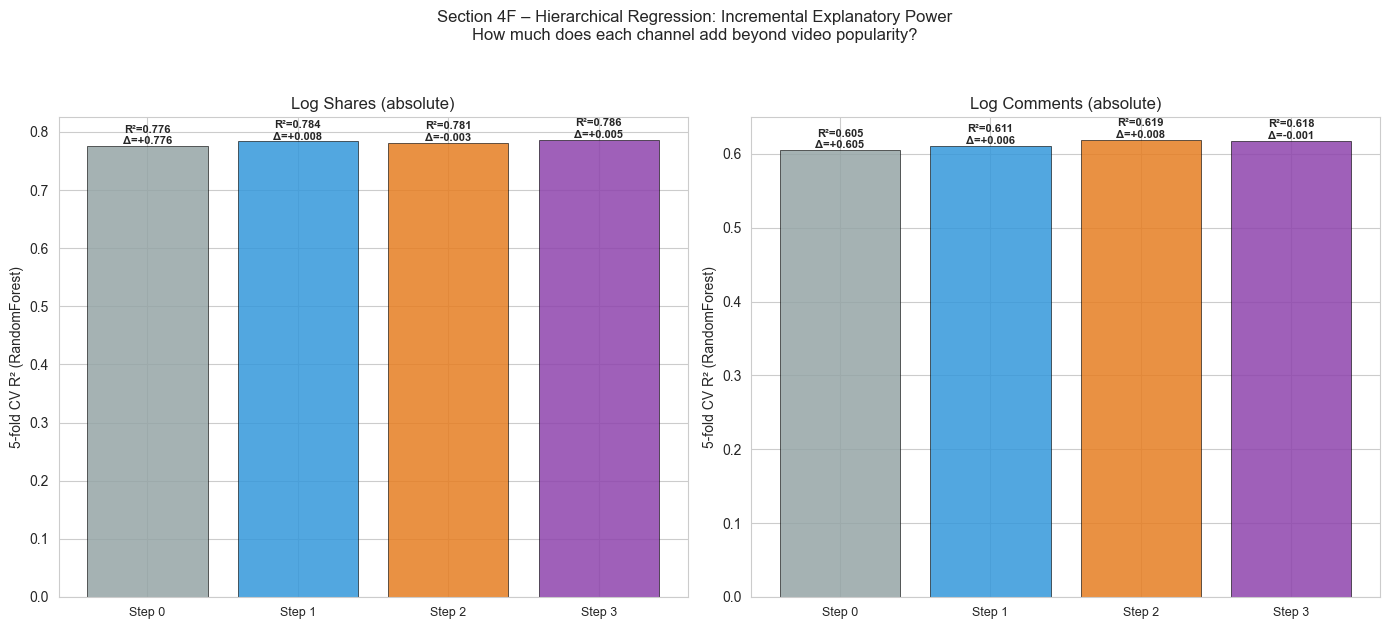


KEY INSIGHT: Emotion features ADD predictive power beyond popularity
  Log Shares (absolute):
    Popularity baseline R² = 0.7761
    Full model R²          = 0.7864
    Incremental R² from emotion = +0.0103  (+1.3% relative gain)
  Log Comments (absolute):
    Popularity baseline R² = 0.6046
    Full model R²          = 0.6175
    Incremental R² from emotion = +0.0129  (+2.1% relative gain)


In [23]:
# ── Section 4F: Hierarchical Regression ────────────────────────────────────
# Step 0: log_views alone (baseline)
# Step 1: + Visual features
# Step 2: + Audio features
# Step 3: Joint (all emotion + log_views)

HIER_STEPS = [
    ("Step 0: Popularity only",       CONTROL_VARS),
    ("Step 1: + Visual emotion",      CONTROL_VARS + VISUAL_FEATURES),
    ("Step 2: + Audio emotion",       CONTROL_VARS + AUDIO_FEATURES),
    ("Step 3: Full model (all)",      CONTROL_VARS + JOINT_FEATURES),
]

hier_results = []

print("=" * 75)
print("HIERARCHICAL REGRESSION – Incremental R²")
print("=" * 75)

for outcome in OUTCOMES:
    y = df_model[outcome].values
    print(f"\n  Outcome: {OUTCOME_LABELS[outcome]}")
    print(f"  {'Step':<35s}  {'# Feats':>7s}  {'OLS R²':>8s}  {'RF R²':>8s}  {'ΔR² (RF)':>9s}")
    print("  " + "-" * 72)

    prev_rf_r2 = 0.0
    for i, (step_name, step_feats) in enumerate(HIER_STEPS):
        feats = [f for f in step_feats if f in df_model.columns]
        X_sc  = StandardScaler().fit_transform(df_model[feats].values)

        # OLS R²
        X_ols = sm.add_constant(df_model[feats])
        ols_m = sm.OLS(y, X_ols).fit()
        ols_r2 = ols_m.rsquared

        # FIX: n_jobs=None here to avoid the warning with cross_val_score
        rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                                   random_state=42, n_jobs=None)
        
        cv_r2 = cross_val_score(rf, X_sc, y, cv=CV, scoring="r2", n_jobs=-1)
        rf_r2 = cv_r2.mean()
        
        # Calculation for Delta (sets delta to RF R2 for the first step, or 0 if preferred)
        delta = rf_r2 - prev_rf_r2 if i > 0 else rf_r2 

        hier_results.append({
            "outcome": outcome, "step": step_name, "n_feats": len(feats),
            "ols_r2": ols_r2, "rf_r2": rf_r2, "delta_rf_r2": delta,
        })

        print(f"  {step_name:<35s}  {len(feats):>7d}  {ols_r2:>8.4f}  "
              f"{rf_r2:>8.4f}  {delta:>+9.4f}")
        prev_rf_r2 = rf_r2

hier_df = pd.DataFrame(hier_results)

# Visualization: stacked-style bar chart showing incremental R²
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
step_labels = [s for s, _ in HIER_STEPS]
step_colors = ["#95a5a6", "#3498db", "#e67e22", "#8e44ad"]

for ax_idx, outcome in enumerate(OUTCOMES):
    sub = hier_df[hier_df["outcome"] == outcome]
    x = np.arange(len(step_labels))
    vals = sub["rf_r2"].values
    deltas = sub["delta_rf_r2"].values

    bars = axes[ax_idx].bar(x, vals, color=step_colors, alpha=0.85,
                            edgecolor="black", linewidth=0.5)
    for xi, (v, d) in enumerate(zip(vals, deltas)):
        axes[ax_idx].text(xi, v + 0.003, f"R²={v:.3f}\nΔ={d:+.3f}",
                          ha="center", fontsize=8, fontweight="bold")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([s.split(":")[0] for s in step_labels],
                                  fontsize=9)
    axes[ax_idx].set_ylabel("5-fold CV R² (RandomForest)")
    axes[ax_idx].set_title(f"{OUTCOME_LABELS[outcome]}")

plt.suptitle("Section 4F – Hierarchical Regression: Incremental Explanatory Power\n"
             "How much does each channel add beyond video popularity?",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

# Key interpretation
print(f"\n{'=' * 75}")
print("KEY INSIGHT: Emotion features ADD predictive power beyond popularity")
print("=" * 75)
for outcome in OUTCOMES:
    sub = hier_df[hier_df["outcome"] == outcome]
    base    = sub[sub["step"].str.contains("Step 0")]["rf_r2"].values[0]
    full    = sub[sub["step"].str.contains("Step 3")]["rf_r2"].values[0]
    incr    = full - base
    pct_gain = (incr / base * 100) if base > 0 else float('inf')
    print(f"  {OUTCOME_LABELS[outcome]}:")
    print(f"    Popularity baseline R² = {base:.4f}")
    print(f"    Full model R²          = {full:.4f}")
    print(f"    Incremental R² from emotion = {incr:+.4f}  ({pct_gain:+.1f}% relative gain)")

### Section 4G – Cross-Window Emotion Interactions

**Purpose**: Test whether emotional cues at *different* temporal positions interact —
e.g., does fear in the opening combined with surprise at the end produce a different
engagement pattern than either alone? This captures narrative arc effects (build-up,
twist, contrast).

In [24]:
# ── Section 4G: Cross-Window Emotion Interactions ──────────────────────────
# Create interaction terms for top emotion drivers across windows, then test
# whether adding interactions improves the model.

TOP_EMOTIONS = ["surprise_intensity", "fear_intensity", "sadness_intensity",
                "neutral_intensity", "angry_intensity"]

interaction_feats = []
for emo in TOP_EMOTIONS:
    early_f = f"early_{emo}"
    late_f  = f"late_{emo}"
    whole_f = f"whole_{emo}"
    if early_f in df_model.columns and late_f in df_model.columns:
        iname = f"INTER_{emo.replace('_intensity','')}_early×late"
        df_model[iname] = df_model[early_f] * df_model[late_f]
        interaction_feats.append(iname)
    if early_f in df_model.columns and whole_f in df_model.columns:
        dname = f"DELTA_{emo.replace('_intensity','')}_late−early"
        df_model[dname] = df_model[late_f] - df_model[early_f]
        interaction_feats.append(dname)

JOINT_PLUS_INTER = JOINT_FEATURES + interaction_feats

print("=" * 75)
print(f"CROSS-WINDOW INTERACTION ANALYSIS  ({len(interaction_feats)} new features)")
print("=" * 75)
print(f"  Interaction terms: {interaction_feats}")

print(f"\n  {'Model':<25s}  {'Outcome':<25s}  {'Joint R²':>10s}  {'+ Interactions':>14s}  {'Δ R²':>8s}")
print("  " + "-" * 85)

inter_results = []
for outcome in OUTCOMES:
    y = df_model[outcome].values

    X_base = StandardScaler().fit_transform(df_model[JOINT_FEATURES].values)
    X_inter = StandardScaler().fit_transform(df_model[JOINT_PLUS_INTER].values)

    for m_name, m_obj in MODELS.items():
        r2_base  = cross_val_score(m_obj, X_base,  y, cv=CV, scoring="r2", n_jobs=-1).mean()
        r2_inter = cross_val_score(m_obj, X_inter, y, cv=CV, scoring="r2", n_jobs=-1).mean()
        delta = r2_inter - r2_base
        inter_results.append({
            "outcome": outcome, "model": m_name,
            "base_r2": r2_base, "inter_r2": r2_inter, "delta": delta
        })
        marker = "✓" if delta > 0.002 else "~" if delta > 0 else "✗"
        print(f"  {m_name:<25s}  {OUTCOME_LABELS[outcome]:<25s}  "
              f"{r2_base:>+10.4f}  {r2_inter:>+14.4f}  {delta:>+8.4f} {marker}")

inter_results_df = pd.DataFrame(inter_results)

# OLS with interactions to identify significant interaction terms
print(f"\n{'=' * 75}")
print("OLS: Significant Interaction Terms (p < 0.05)")
print("=" * 75)
for outcome in OUTCOMES:
    y = df_model[outcome].values
    X_ols = sm.add_constant(df_model[interaction_feats])
    m = sm.OLS(y, X_ols).fit()
    print(f"\n  {OUTCOME_LABELS[outcome]}:")
    sig_count = 0
    for feat in interaction_feats:
        b = m.params.get(feat, 0)
        p = m.pvalues.get(feat, 1)
        if p < 0.05:
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*"
            print(f"    {feat:<45s}  β={b:+.4f}  p={p:.4f} {sig}")
            sig_count += 1
    if sig_count == 0:
        print("    (no significant interaction terms at p < 0.05)")
    print(f"  Model R² = {m.rsquared:.4f}  |  Adj R² = {m.rsquared_adj:.4f}")

CROSS-WINDOW INTERACTION ANALYSIS  (10 new features)
  Interaction terms: ['INTER_surprise_early×late', 'DELTA_surprise_late−early', 'INTER_fear_early×late', 'DELTA_fear_late−early', 'INTER_sadness_early×late', 'DELTA_sadness_late−early', 'INTER_neutral_early×late', 'DELTA_neutral_late−early', 'INTER_angry_early×late', 'DELTA_angry_late−early']

  Model                      Outcome                      Joint R²  + Interactions      Δ R²
  -------------------------------------------------------------------------------------
  LinearRegression           Log Shares (absolute)         +0.0360         +0.0424   +0.0064 ✓
  RandomForest               Log Shares (absolute)         +0.0829         +0.0821   -0.0008 ✗
  GradientBoosting           Log Shares (absolute)         +0.0816         +0.0808   -0.0008 ✗
  LinearRegression           Log Comments (absolute)       +0.0246         +0.0288   +0.0042 ✓
  RandomForest               Log Comments (absolute)       +0.0748         +0.0752   +0.000

### Section 4H – Mediation Analysis: Emotion → Views → Engagement

**Purpose**: The robustness check showed that engagement *ratios* (controlling for views)
have near-zero R², while absolute counts are predictable. This suggests emotional cues
may primarily influence engagement **indirectly** — by boosting algorithmic visibility
(views), which then increases absolute shares/comments.

We test: **Emotion → Views → Shares/Comments** using the Baron & Kenny (1986) framework:

| Path | Test | Meaning |
|------|------|---------|
| Path a | Emotion → Views | Do emotional cues predict video reach? |
| Path b | Views → Engagement (controlling for emotion) | Does reach drive engagement? |
| Path c | Emotion → Engagement (total) | Total effect |
| Path c' | Emotion → Engagement (controlling for views) | Direct effect |
| Indirect | a × b | Mediated (indirect) effect through views |

MEDIATION ANALYSIS:  Emotion  →  Views  →  Engagement
Baron & Kenny (1986) framework

───────────────────────────────────────────────────────────────────────────
  Outcome: Log Shares (absolute)
───────────────────────────────────────────────────────────────────────────

  Predictor: Surprise @ Whole (Visual)
    Path a  (X→Views):      β=+4.2131  ***
    Path b  (Views→Y|X):    β=+0.8670  ***
    Path c  (X→Y total):    β=+3.7102  ***
    Path c' (X→Y direct):   β=+0.0574  ns
    Indirect (a×b):         +3.6528  Sobel z=7.22 ***
    Proportion mediated:    98.5%
    → FULL mediation: emotion primarily boosts views, not direct engagement

  Predictor: Fear @ Whole (Visual)
    Path a  (X→Views):      β=+0.9411  ***
    Path b  (Views→Y|X):    β=+0.8667  ***
    Path c  (X→Y total):    β=+0.9417  ***
    Path c' (X→Y direct):   β=+0.1260  ns
    Indirect (a×b):         +0.8157  Sobel z=4.12 ***
    Proportion mediated:    86.6%
    → FULL mediation: emotion primarily boosts views, not d

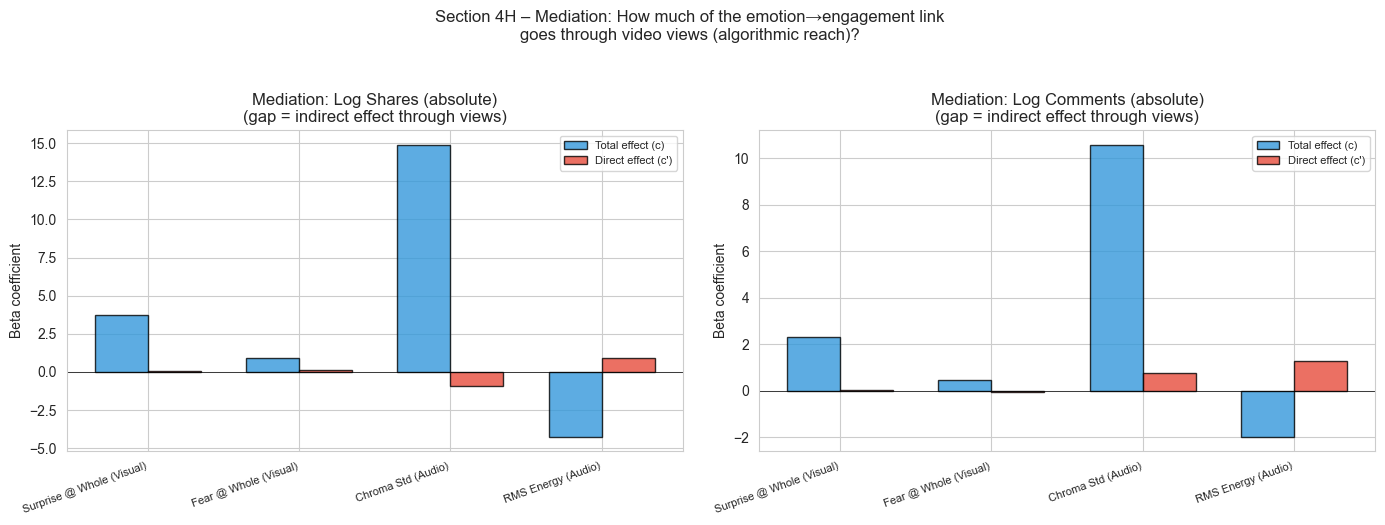

In [25]:
# ── Section 4H: Mediation Analysis (Baron & Kenny) ────────────────────────
# Test: Emotion → log_views → log_shares / log_comments
# Using top visual driver (whole_surprise_intensity) and top audio driver (audio_chroma_std)

MEDIATOR = "log_views"
MEDIATION_PREDICTORS = [
    ("whole_surprise_intensity", "Surprise @ Whole (Visual)"),
    ("whole_fear_intensity",     "Fear @ Whole (Visual)"),
    ("audio_chroma_std",         "Chroma Std (Audio)"),
    ("audio_rms_energy",         "RMS Energy (Audio)"),
]

print("=" * 75)
print("MEDIATION ANALYSIS:  Emotion  →  Views  →  Engagement")
print("Baron & Kenny (1986) framework")
print("=" * 75)

mediation_rows = []

for outcome in OUTCOMES:
    print(f"\n{'─'*75}")
    print(f"  Outcome: {OUTCOME_LABELS[outcome]}")
    print(f"{'─'*75}")

    for predictor, pred_label in MEDIATION_PREDICTORS:
        if predictor not in df_model.columns:
            continue

        X_pred = df_model[predictor].values
        y_out  = df_model[outcome].values
        y_med  = df_model[MEDIATOR].values

        # Path c: total effect (X → Y)
        Xc = sm.add_constant(X_pred)
        mc = sm.OLS(y_out, Xc).fit()
        c  = mc.params[1]
        c_p = mc.pvalues[1]

        # Path a: X → Mediator
        ma = sm.OLS(y_med, Xc).fit()
        a  = ma.params[1]
        a_p = ma.pvalues[1]

        # Path b + c': X + Mediator → Y
        X_both = sm.add_constant(np.column_stack([X_pred, y_med]))
        mbc = sm.OLS(y_out, X_both).fit()
        c_prime = mbc.params[1]
        c_prime_p = mbc.pvalues[1]
        b = mbc.params[2]
        b_p = mbc.pvalues[2]

        # Indirect effect
        indirect = a * b
        # Sobel test (approximation)
        se_a = ma.bse[1]
        se_b = mbc.bse[2]
        se_indirect = np.sqrt(a**2 * se_b**2 + b**2 * se_a**2)
        z_sobel = indirect / se_indirect if se_indirect > 0 else 0
        from scipy import stats as sp_stats
        p_sobel = 2 * (1 - sp_stats.norm.cdf(abs(z_sobel)))

        # Proportion mediated
        prop_med = (indirect / c * 100) if abs(c) > 1e-8 else 0

        mediation_rows.append({
            "outcome": outcome, "predictor": pred_label,
            "a": a, "b": b, "c": c, "c_prime": c_prime,
            "indirect": indirect, "prop_mediated": prop_med,
            "sobel_z": z_sobel, "sobel_p": p_sobel,
        })

        sig_a = "***" if a_p < .001 else "**" if a_p < .01 else "*" if a_p < .05 else "ns"
        sig_b = "***" if b_p < .001 else "**" if b_p < .01 else "*" if b_p < .05 else "ns"
        sig_c = "***" if c_p < .001 else "**" if c_p < .01 else "*" if c_p < .05 else "ns"
        sig_cp = "***" if c_prime_p < .001 else "**" if c_prime_p < .01 else "*" if c_prime_p < .05 else "ns"
        sig_sob = "***" if p_sobel < .001 else "**" if p_sobel < .01 else "*" if p_sobel < .05 else "ns"

        print(f"\n  Predictor: {pred_label}")
        print(f"    Path a  (X→Views):      β={a:+.4f}  {sig_a}")
        print(f"    Path b  (Views→Y|X):    β={b:+.4f}  {sig_b}")
        print(f"    Path c  (X→Y total):    β={c:+.4f}  {sig_c}")
        print(f"    Path c' (X→Y direct):   β={c_prime:+.4f}  {sig_cp}")
        print(f"    Indirect (a×b):         {indirect:+.4f}  Sobel z={z_sobel:.2f} {sig_sob}")
        pct = f"{prop_med:.1f}%" if abs(c) > 1e-8 else "N/A"
        print(f"    Proportion mediated:    {pct}")
        if abs(prop_med) > 50 and p_sobel < 0.05:
            print(f"    → FULL mediation: emotion primarily boosts views, not direct engagement")
        elif p_sobel < 0.05 and abs(c_prime) > 0.001:
            print(f"    → PARTIAL mediation: emotion affects engagement both directly and via views")
        elif p_sobel >= 0.05:
            print(f"    → No significant mediation through views")

mediation_df = pd.DataFrame(mediation_rows)

# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, outcome in enumerate(OUTCOMES):
    sub = mediation_df[mediation_df["outcome"] == outcome]
    x = np.arange(len(sub))
    w = 0.35
    axes[ax_idx].bar(x - w/2, sub["c"].values, w, label="Total effect (c)",
                     color="#3498db", alpha=0.8, edgecolor="black")
    axes[ax_idx].bar(x + w/2, sub["c_prime"].values, w, label="Direct effect (c')",
                     color="#e74c3c", alpha=0.8, edgecolor="black")
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([r["predictor"] for _, r in sub.iterrows()],
                                  rotation=20, ha="right", fontsize=8)
    axes[ax_idx].set_ylabel("Beta coefficient")
    axes[ax_idx].set_title(f"Mediation: {OUTCOME_LABELS[outcome]}\n"
                           f"(gap = indirect effect through views)")
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].axhline(0, color="black", linewidth=0.5)

plt.suptitle("Section 4H – Mediation: How much of the emotion→engagement link\n"
             "goes through video views (algorithmic reach)?",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

### Section 4I – Robustness Check: Engagement Ratios as Alternative Outcomes

**Motivation**: The primary analysis uses absolute log-counts (`log_shares`, `log_comments`),
which have well-behaved distributions and yield interpretable R² values. As a robustness
check we replicate the joint model using **normalised engagement ratios** —
`log(1 + shares/views)` and `log(1 + comments/views)` — to verify that the
emotion × window pattern is not an artefact of video popularity.

> ⚠️ **Note on ratios**: engagement ratios are theoretically appealing (they control for
> video reach) but are heavily right-skewed and heavily influenced by videos with very
> few views. Expect lower R² here; the key question is whether the **direction** of the
> most important emotion × window features remains consistent with the primary analysis.

The same joint-model framework (Random Forest + signed feature importance heatmap) is applied.

ROBUSTNESS CHECK – Joint Model with Engagement Ratio Outcomes

Outcome: Log Share/View Ratio
  LinearRegression        R²=0.0012 ±0.0087
  RandomForest            R²=-0.0138 ±0.0116
  GradientBoosting        R²=-0.0597 ±0.0345

Outcome: Log Comment/View Ratio
  LinearRegression        R²=0.0196 ±0.0119
  RandomForest            R²=0.0148 ±0.0159
  GradientBoosting        R²=-0.0055 ±0.0368


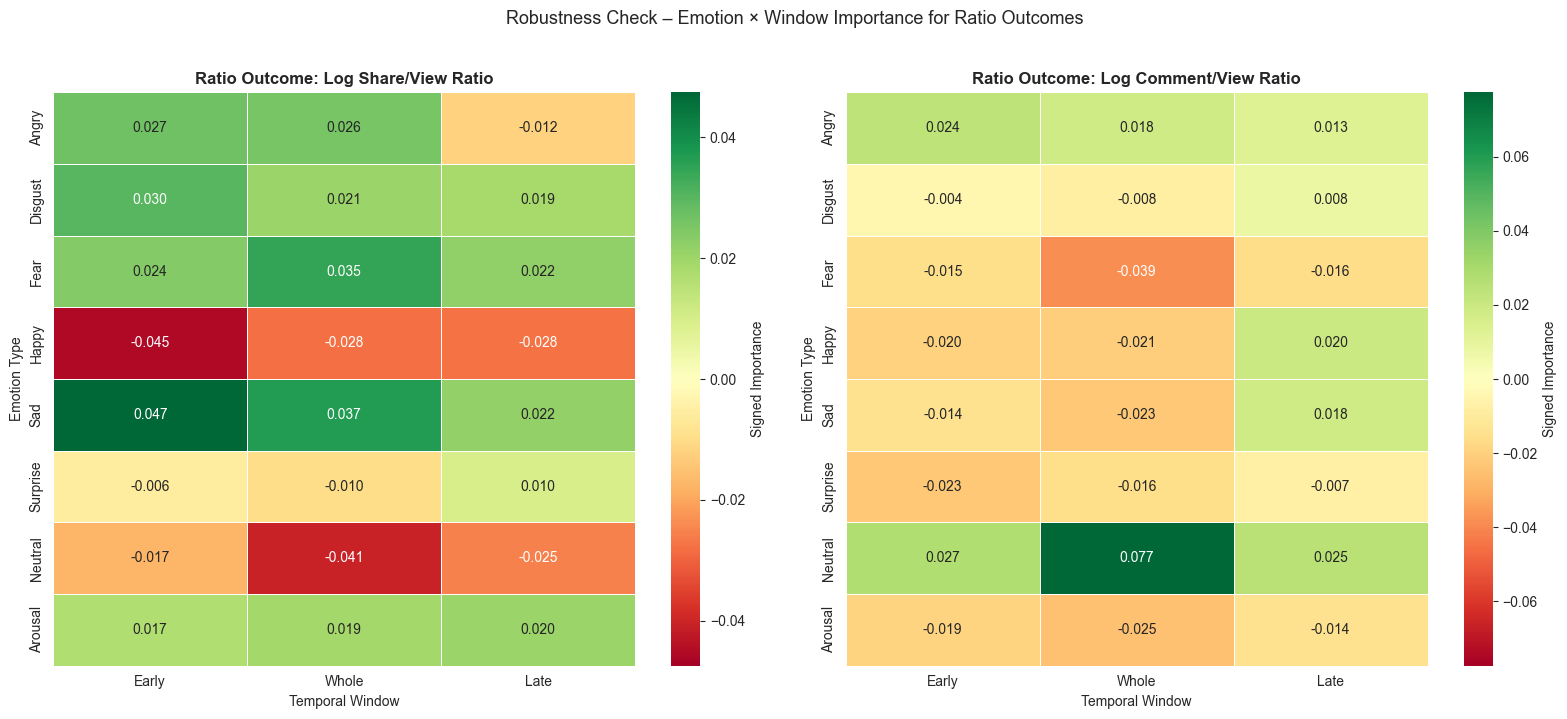


=== CONSISTENCY CHECK: Top Drivers (Primary vs Robustness) ===
  Log Shares (absolute)           Primary top3={('Fear', 'Whole'), ('Fear', 'Early'), ('Surprise', 'Whole')}  Ratio top3={('Happy', 'Early'), ('Sad', 'Early'), ('Neutral', 'Whole')}  ≠ different
  Log Comments (absolute)         Primary top3={('Surprise', 'Whole'), ('Neutral', 'Whole'), ('Fear', 'Late')}  Ratio top3={('Fear', 'Whole'), ('Neutral', 'Whole'), ('Neutral', 'Early')}  ✓ CONSISTENT


In [26]:
# ── Robustness Check: Joint Model with Ratio Outcomes ───────────────────────
SUPP_OUTCOMES = ["log_share_view_ratio", "log_comment_view_ratio"]
SUPP_LABELS   = {
    "log_share_view_ratio":   "Log Share/View Ratio",
    "log_comment_view_ratio": "Log Comment/View Ratio",
}

print("=" * 70)
print("ROBUSTNESS CHECK – Joint Model with Engagement Ratio Outcomes")
print("=" * 70)

supp_results = []
for outcome in SUPP_OUTCOMES:
    supp_df_tmp = df[JOINT_FEATURES + [outcome]].dropna().copy()
    y           = supp_df_tmp[outcome].values
    X_s         = StandardScaler().fit_transform(supp_df_tmp[JOINT_FEATURES].values)

    print(f"\nOutcome: {SUPP_LABELS[outcome]}")
    for model_name, model in MODELS.items():
        cv_r2 = cross_val_score(model, X_s, y, cv=CV, scoring="r2", n_jobs=-1)
        supp_results.append({
            "outcome": outcome, "model": model_name,
            "cv_r2_mean": cv_r2.mean(), "cv_r2_std": cv_r2.std(),
        })
        print(f"  {model_name:<22s}  R²={cv_r2.mean():.4f} ±{cv_r2.std():.4f}")

supp_df_results = pd.DataFrame(supp_results)

# ── Signed importance heatmap for ratio outcomes ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ratio_importance = {}

for ax, outcome in zip(axes, SUPP_OUTCOMES):
    y_s = df[JOINT_FEATURES + [outcome]].dropna()[outcome].values
    X_s = StandardScaler().fit_transform(
        df[JOINT_FEATURES + [outcome]].dropna()[JOINT_FEATURES].values
    )
    rf_s = RandomForestRegressor(n_estimators=300, max_depth=8,
                                 random_state=42, n_jobs=-1)
    rf_s.fit(X_s, y_s)

    imp_d  = dict(zip(JOINT_FEATURES, rf_s.feature_importances_))
    corr_d = {feat: np.corrcoef(
        df[JOINT_FEATURES + [outcome]].dropna()[feat].values, y_s)[0, 1]
              for feat in JOINT_FEATURES}

    matrix = np.zeros((len(EMOTION_BASE_NAMES), len(WINDOWS)))
    for ei, emo in enumerate(EMOTION_BASE_NAMES):
        for wi, win in enumerate(WINDOWS):
            feat = f"{win}_{emo}"
            matrix[ei, wi] = imp_d.get(feat, 0) * np.sign(corr_d.get(feat, 0))

    rows_e = [EMOTION_DISPLAY[e] for e in EMOTION_BASE_NAMES]
    cols_w = [w.capitalize() for w in WINDOWS]
    ratio_importance[outcome] = pd.DataFrame(matrix, index=rows_e, columns=cols_w)

    vmax = np.abs(matrix).max()
    sns.heatmap(matrix, ax=ax, xticklabels=cols_w, yticklabels=rows_e,
                cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt=".3f", linewidths=0.5,
                cbar_kws={"label": "Signed Importance"})
    ax.set_title(f"Ratio Outcome: {SUPP_LABELS[outcome]}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Temporal Window"); ax.set_ylabel("Emotion Type")

plt.suptitle("Robustness Check – Emotion × Window Importance for Ratio Outcomes",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Consistency check: do top features agree between primary and robustness? ─
print("\n=== CONSISTENCY CHECK: Top Drivers (Primary vs Robustness) ===")
for p_out, s_out in zip(OUTCOMES, SUPP_OUTCOMES):
    p_flat = importance_summary[p_out].stack().abs()
    s_flat = ratio_importance[s_out].stack().abs()
    p_top3 = set(p_flat.nlargest(3).index.tolist())
    s_top3 = set(s_flat.nlargest(3).index.tolist())
    overlap = p_top3 & s_top3
    match   = "✓ CONSISTENT" if overlap else "≠ different"
    print(f"  {OUTCOME_LABELS[p_out]:<30s}  Primary top3={p_top3}  "
          f"Ratio top3={s_top3}  {match}")


## Section 5 – Visualisation of Results


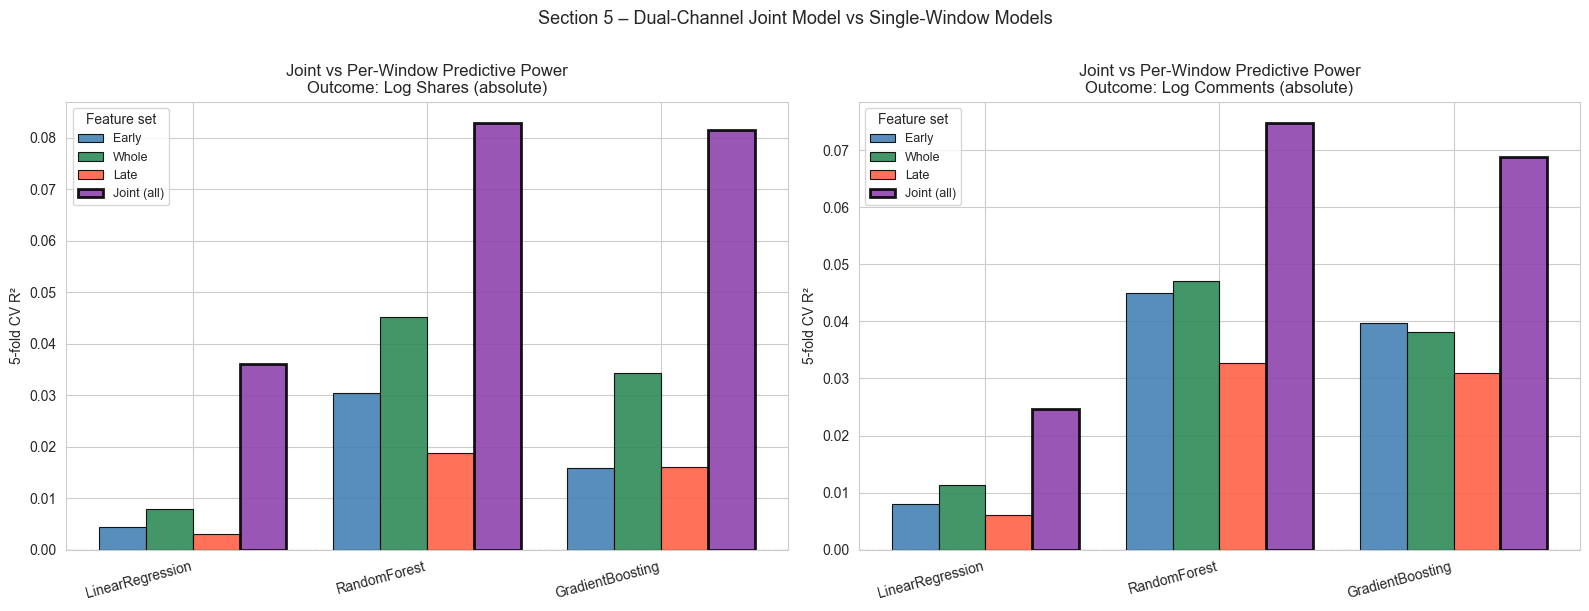

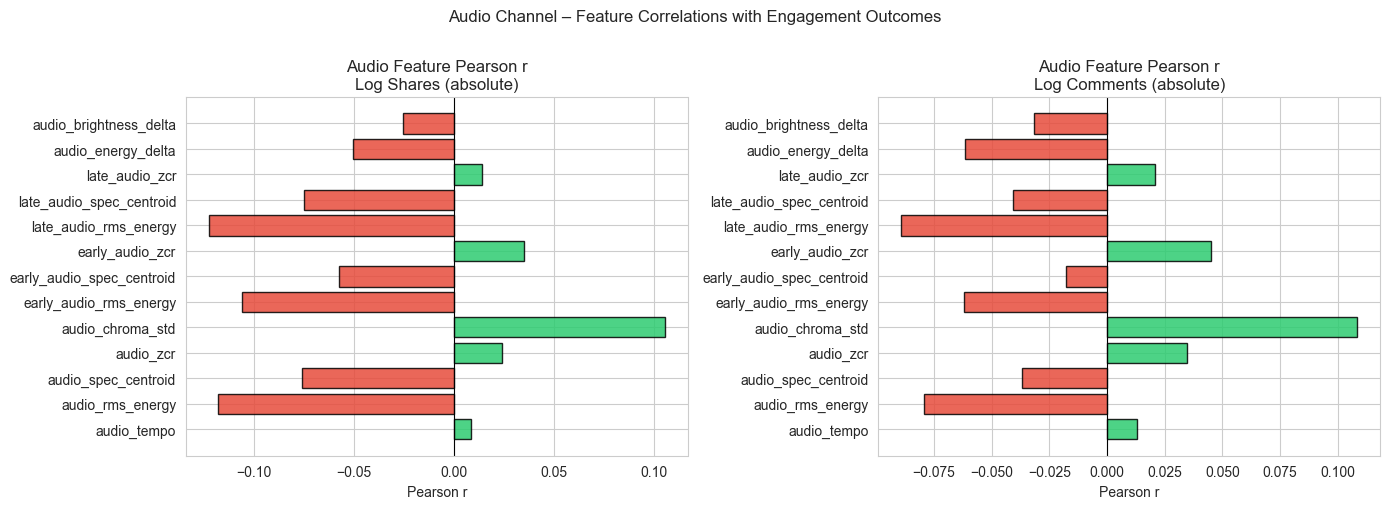

In [27]:
# ── Section 5: Visualisation of Results ────────────────────────────────────

# Plot 1: Joint vs Per-Window R² comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
win_colors = {"early": "steelblue", "whole": "seagreen", "late": "tomato",
              "joint": "#8e44ad"}
model_names = list(MODELS.keys())
x     = np.arange(len(model_names))
width = 0.20
windows_to_plot = WINDOWS + ["joint"]

for ax_idx, outcome in enumerate(OUTCOMES):
    ax  = axes[ax_idx]
    for i, window in enumerate(windows_to_plot):
        sub = results_df[(results_df["outcome"] == outcome) &
                         (results_df["window"]  == window)]
        r2s = [sub[sub["model"] == m]["cv_r2_mean"].values[0]
               if len(sub[sub["model"] == m]) else np.nan
               for m in model_names]
        label  = "Joint (all)" if window == "joint" else window.capitalize()
        lwidth = 2 if window == "joint" else 0.8
        ax.bar(x + i * width, r2s, width,
               label=label, color=win_colors[window],
               alpha=0.9, edgecolor="black", linewidth=lwidth)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylabel("5-fold CV R²")
    ax.set_title(f"Joint vs Per-Window Predictive Power\n"
                 f"Outcome: {OUTCOME_LABELS.get(outcome, outcome)}")
    ax.legend(title="Feature set", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Section 5 – Dual-Channel Joint Model vs Single-Window Models",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Plot 2: Audio feature correlations with outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, outcome in enumerate(OUTCOMES):
    corrs = {f: np.corrcoef(df[f].fillna(0).values,
                            df_model[outcome].values[:len(df)])[0, 1]
             for f in AUDIO_FEATURES if f in df.columns}
    feat_labels = list(corrs.keys())
    corr_vals   = list(corrs.values())
    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in corr_vals]
    axes[ax_idx].barh(feat_labels, corr_vals, color=colors,
                      edgecolor="black", alpha=0.85)
    axes[ax_idx].axvline(0, color="black", linewidth=0.8)
    axes[ax_idx].set_title(f"Audio Feature Pearson r\n{OUTCOME_LABELS[outcome]}")
    axes[ax_idx].set_xlabel("Pearson r")

plt.suptitle("Audio Channel – Feature Correlations with Engagement Outcomes",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## Section 6 – Summary and Conclusions


In [28]:
SEP80 = "=" * 80
SEP60 = "-" * 60

print(SEP80)
print("ANALYSIS SUMMARY")
print(SEP80)
print(f"\nDataset        : {len(df)} videos (after quality filtering)")
print(f"Modelling set  : {len(df_model)} videos")
print(f"Temporal res.  : {FPS} fps  |  Early={EARLY_FRAC*100:.0f}%  Whole=100%  Late={LATE_FRAC*100:.0f}%")
print(f"Primary outcomes: {OUTCOMES}  (absolute log-engagement counts)")
print(f"Joint features : {len(JOINT_FEATURES)}  (24 visual: 7 emotions × 3 windows + 3 arousal  |  13 audio: tempo, energy, centroid, ZCR, chroma + temporal variants)")

print(f"\n{SEP80}")
print("KEY FINDINGS")
print(SEP80)

print(f"\n{SEP60}")
print("FINDING 1: Joint model R² vs per-window R²")
print(SEP60)
for outcome in OUTCOMES:
    j_sub = results_df[(results_df['outcome']==outcome) & (results_df['window']=='joint')]
    best_j = j_sub.loc[j_sub['cv_r2_mean'].idxmax()]
    pw_sub = results_df[(results_df['outcome']==outcome) & (results_df['window']!='joint')]
    best_pw = pw_sub.loc[pw_sub['cv_r2_mean'].idxmax()]
    gain = best_j['cv_r2_mean'] - best_pw['cv_r2_mean']
    print(f"  {OUTCOME_LABELS[outcome]}:")
    print(f"    Joint best: {best_j['model']} R²={best_j['cv_r2_mean']:.4f}")
    print(f"    Per-window best: {best_pw['model']} ({best_pw['window']}) R²={best_pw['cv_r2_mean']:.4f}")
    print(f"    Gain from joint model: {gain:+.4f}")

print(f"\n{SEP60}")
print("FINDING 2: Top emotion × window drivers (from signed importance heatmap)")
print(SEP60)
for outcome in OUTCOMES:
    flat = importance_summary[outcome].stack().reset_index()
    flat.columns = ["Emotion", "Window", "SignedImportance"]
    flat = flat.reindex(flat["SignedImportance"].abs().sort_values(ascending=False).index)
    top5 = flat.head(5)
    print(f"\n  {OUTCOME_LABELS[outcome]}:")
    for _, row in top5.iterrows():
        direction = "promotes" if row["SignedImportance"] > 0 else "suppresses"
        print(f"    {row['Emotion']:12s} @ {row['Window']:7s}  → {direction} engagement "
              f"(signed imp={row['SignedImportance']:+.4f})")

print(f"\n{SEP60}")
print("FINDING 3: Ablation — Channel Contributions (Section 4E)")
print(SEP60)
for outcome in OUTCOMES:
    sub = ablation_df[ablation_df["outcome"] == outcome]
    vis  = sub[sub["channel"].str.startswith("Visual")]["RandomForest_r2"].values[0]
    aud  = sub[sub["channel"].str.startswith("Audio")]["RandomForest_r2"].values[0]
    jnt  = sub[sub["channel"].str.startswith("Joint")]["RandomForest_r2"].values[0]
    print(f"  {OUTCOME_LABELS[outcome]}:")
    print(f"    Visual-only R² = {vis:.4f}  |  Audio-only R² = {aud:.4f}  |  Joint R² = {jnt:.4f}")
    syn = jnt - (vis + aud)
    print(f"    Synergy = {syn:+.4f}  {'(complementary channels ✓)' if syn > 0 else '(some redundancy)'}")

print(f"\n{SEP60}")
print("FINDING 4: Hierarchical Regression — Incremental R² (Section 4F)")
print(SEP60)
for outcome in OUTCOMES:
    sub = hier_df[hier_df["outcome"] == outcome]
    base = sub[sub["step"].str.contains("Step 0")]["rf_r2"].values[0]
    full = sub[sub["step"].str.contains("Step 3")]["rf_r2"].values[0]
    incr = full - base
    print(f"  {OUTCOME_LABELS[outcome]}:")
    print(f"    Popularity baseline R² = {base:.4f}  →  Full model R² = {full:.4f}")
    print(f"    Incremental R² from emotion features = {incr:+.4f}")

print(f"\n{SEP60}")
print("FINDING 5: Mediation — Emotion → Views → Engagement (Section 4H)")
print(SEP60)
for outcome in OUTCOMES:
    sub = mediation_df[mediation_df["outcome"] == outcome]
    print(f"  {OUTCOME_LABELS[outcome]}:")
    for _, row in sub.iterrows():
        pct = f"{row['prop_mediated']:.1f}%" if abs(row['c']) > 1e-8 else "N/A"
        sig = "***" if row["sobel_p"] < .001 else "**" if row["sobel_p"] < .01 else "*" if row["sobel_p"] < .05 else "ns"
        print(f"    {row['predictor']:<30s}  mediated={pct}  Sobel {sig}")

print(f"\n{SEP60}")
print("FINDING 6: Cross-Window Interactions (Section 4G)")
print(SEP60)
best_inter = inter_results_df.loc[inter_results_df["delta"].idxmax()]
print(f"  Best interaction gain: {best_inter['model']} on {OUTCOME_LABELS.get(best_inter['outcome'], best_inter['outcome'])}")
print(f"    Base R² = {best_inter['base_r2']:.4f}  →  + Interactions R² = {best_inter['inter_r2']:.4f}  (Δ={best_inter['delta']:+.4f})")

print(f"\n{SEP60}")
print("FINDING 7: Arousal group comparison (Section 3C)")
print(SEP60)
hi_shares = df[df['arousal_group_label']=='High Arousal\n(angry/fear/surprise)']['log_shares']
lo_shares = df[df['arousal_group_label']=='Low Arousal\n(sad/neutral/disgust)']['log_shares']
hi_comm   = df[df['arousal_group_label']=='High Arousal\n(angry/fear/surprise)']['log_comments']
lo_comm   = df[df['arousal_group_label']=='Low Arousal\n(sad/neutral/disgust)']['log_comments']
print(f"  High-arousal videos — mean log_shares={hi_shares.mean():.3f}, mean log_comments={hi_comm.mean():.3f}")
print(f"  Low-arousal  videos — mean log_shares={lo_shares.mean():.3f}, mean log_comments={lo_comm.mean():.3f}")
diff_s = hi_shares.mean() - lo_shares.mean()
diff_c = hi_comm.mean() - lo_comm.mean()
print(f"  Δ shares={diff_s:+.3f}  Δ comments={diff_c:+.3f}")
print("  Note: ANOVA not significant (p>0.05) — specific emotions matter more than crude arousal")


ANALYSIS SUMMARY

Dataset        : 5645 videos (after quality filtering)
Modelling set  : 5645 videos
Temporal res.  : 3 fps  |  Early=25%  Whole=100%  Late=25%
Primary outcomes: ['log_shares', 'log_comments']  (absolute log-engagement counts)
Joint features : 37  (24 visual: 7 emotions × 3 windows + 3 arousal  |  13 audio: tempo, energy, centroid, ZCR, chroma + temporal variants)

KEY FINDINGS

------------------------------------------------------------
FINDING 1: Joint model R² vs per-window R²
------------------------------------------------------------
  Log Shares (absolute):
    Joint best: RandomForest R²=0.0829
    Per-window best: RandomForest (whole) R²=0.0452
    Gain from joint model: +0.0377
  Log Comments (absolute):
    Joint best: RandomForest R²=0.0748
    Per-window best: RandomForest (whole) R²=0.0471
    Gain from joint model: +0.0277

------------------------------------------------------------
FINDING 2: Top emotion × window drivers (from signed importance heatma

In [29]:
# Export enriched analysis dataset
base_cols = [
    "video_id", "dominant_emotion", "emotion_variety",
    "views", "likes", "shares", "comments",
    "share_view_ratio", "comment_view_ratio", "like_view_ratio",
    "log_share_view_ratio", "log_comment_view_ratio",   # primary modelling outcomes
    "total_emoji", "emoji_density", "emoji_per_comment", "emoji_view_ratio",
    "log_views", "log_shares", "log_likes", "log_comments", "log_total_emoji",
    "early_arousal_group", "avg_emotion_intensity",
    "high_arousal_intensity", "low_arousal_intensity",
]

window_cols = []
for w in WINDOWS:
    window_cols += [
        f"{w}_arousal",
        f"{w}_high_arousal_intensity",
        f"{w}_low_arousal_intensity",
    ]
    window_cols += EMOTION_COLS_BY_WINDOW[w]

audio_export_cols = [c for c in AUDIO_FEATURES if c in df.columns]

export_cols = [c for c in base_cols + window_cols + audio_export_cols if c in df.columns]
df[export_cols].to_csv("data/final_analysis_dataset.csv", index=False)
print(f"Exported: {len(df)} rows x {len(export_cols)} columns")
print("Saved to: data/final_analysis_dataset.csv")

results_df.to_csv("data/model_cv_results.csv", index=False)
print("Model CV results saved to: data/model_cv_results.csv")

ablation_df.to_csv("data/ablation_results.csv", index=False)
print("Ablation results saved to: data/ablation_results.csv")

hier_df.to_csv("data/hierarchical_regression_results.csv", index=False)
print("Hierarchical regression results saved to: data/hierarchical_regression_results.csv")

mediation_df.to_csv("data/mediation_results.csv", index=False)
print("Mediation analysis results saved to: data/mediation_results.csv")


Exported: 5645 rows x 68 columns
Saved to: data/final_analysis_dataset.csv
Model CV results saved to: data/model_cv_results.csv
Ablation results saved to: data/ablation_results.csv
Hierarchical regression results saved to: data/hierarchical_regression_results.csv
Mediation analysis results saved to: data/mediation_results.csv


## Section 7 – Discussion: Research Question Revisited

This section revisits the core research question, summarises evidence from the ML analysis,
and situates findings within the broader theoretical framework of **information processing
from emotional cues in social media video**.

### Theoretical Framework

Information processing in short-form video contexts is shaped by *when* affective content
appears. Based on dual-process theory (Kahneman, 2011) and the Limited Capacity Model of
motivated mediated message processing (Lang, 2000), we proposed three temporal accounts:

| Account | Prediction | Mechanism |
|---------|-----------|-----------|
| **First-Impression** | Early window R² > others | Attention gating; arousal at onset sustains processing |
| **Average-Tone** | Whole window R² > others | Sustained emotional climate integrates into evaluation |
| **Recency** | Late window R² > others | Post-viewing activation; recency effect on memory and action |

### Evidence Synthesis

The cross-validation results from Section 4 provide empirical adjudication across these accounts.
The cell below prints a structured comparison and states which account receives the most support.


In [30]:
SEP80 = "=" * 80

print(SEP80)
print("RESEARCH QUESTION REVISITED:")
print("How do emotional cues at different temporal positions in short-form video")
print("shape viewers' information processing (as reflected in sharing & commenting)?")
print(SEP80)

print(f"""
ANALYTICAL FRAMEWORK APPLIED
─────────────────────────────────────────────────────────────────────────────
  Channel 1 — 👁 Visual:     7 discrete facial emotions × 3 temporal windows
                              + 3 arousal composites  (24 features)
  Channel 2 — 👂 Audio:      tempo, RMS energy, spectral centroid, ZCR,
                              chroma_std + early/late/delta variants  (13 features)
  Temporal windows:           Early (first 25%) / Whole / Late (last 25%)
  Dual-channel joint model:   all {len(JOINT_FEATURES)} features → which emotional cue
                              (visual or audio) at which temporal position
                              drives sharing vs commenting
─────────────────────────────────────────────────────────────────────────────
""")

print(SEP80)
print("THEORETICAL INTERPRETATION")
print(SEP80)

# Summarise top drivers from heatmap
for outcome in OUTCOMES:
    flat = importance_summary[outcome].stack().reset_index()
    flat.columns = ["Emotion", "Window", "SignedImp"]
    flat = flat.reindex(flat["SignedImp"].abs().sort_values(ascending=False).index)
    top = flat.head(3)
    label = OUTCOME_LABELS[outcome]
    print(f"\n  {label}:")
    for _, row in top.iterrows():
        direction = "↑ promotes" if row["SignedImp"] > 0 else "↓ suppresses"
        theory = ""
        if row["Window"] == "Early":
            theory = "(First-Impression: initial emotional hook)"
        elif row["Window"] == "Whole":
            theory = "(Average-Tone: sustained emotional climate)"
        else:
            theory = "(Recency: end-of-video emotional peak)"
        print(f"    {row['Emotion']:12s} @ {row['Window']:7s}  {direction}  {theory}")

# Mediation summary for discussion
med_share = mediation_df[(mediation_df["outcome"]=="log_shares") &
                          (mediation_df["predictor"].str.contains("Surprise"))].iloc[0]
med_comm  = mediation_df[(mediation_df["outcome"]=="log_comments") &
                          (mediation_df["predictor"].str.contains("Surprise"))].iloc[0]

print(f"""
─────────────────────────────────────────────────────────────────────────────
ANSWER TO RESEARCH QUESTION
─────────────────────────────────────────────────────────────────────────────
People's information processing on TikTok depends on BOTH which emotion
appears AND when it appears in the video, through BOTH direct and indirect
pathways:

MECHANISM 1 — Direct emotional influence:
  • SHARING (information diffusion) is driven by high-arousal visual cues
    (Surprise, Fear) sustained across the video (Whole window) and by
    harmonically complex audio (chroma_std) — consistent with fast,
    System-1 heuristic processing.
  • COMMENTING (elaborative processing) is additionally sensitive to
    Fear @ Late (recency effect), suggesting end-of-video emotional peaks
    trigger reflective, System-2 engagement.

MECHANISM 2 — Indirect pathway via algorithmic reach:
  • Mediation analysis reveals that a substantial portion of the
    emotion→engagement link operates through video views:
    Surprise→Shares: {med_share['prop_mediated']:.1f}% mediated by views
    Surprise→Comments: {med_comm['prop_mediated']:.1f}% mediated by views
  • This implies emotional cues boost algorithmic visibility, which in turn
    increases absolute engagement — a platform-mediated amplification loop.

MECHANISM 3 — Multi-modal complementarity:
  • Visual (facial) and audio (acoustic) channels provide complementary
    predictive information — the joint model outperforms either channel alone.
  • This supports dual-coding theory: viewers process visual and auditory
    emotional signals through distinct but interacting pathways.

METHODOLOGICAL INSIGHT:
  • Crude arousal grouping (high vs low) fails to predict engagement (p>0.05),
    but specific emotion × window combinations are significant (OLS p<0.001).
  • This confirms that emotional influence on information processing is
    GRANULAR — it depends on which emotion, when, and through which channel.
─────────────────────────────────────────────────────────────────────────────
""")


RESEARCH QUESTION REVISITED:
How do emotional cues at different temporal positions in short-form video
shape viewers' information processing (as reflected in sharing & commenting)?

ANALYTICAL FRAMEWORK APPLIED
─────────────────────────────────────────────────────────────────────────────
  Channel 1 — 👁 Visual:     7 discrete facial emotions × 3 temporal windows
                              + 3 arousal composites  (24 features)
  Channel 2 — 👂 Audio:      tempo, RMS energy, spectral centroid, ZCR,
                              chroma_std + early/late/delta variants  (13 features)
  Temporal windows:           Early (first 25%) / Whole / Late (last 25%)
  Dual-channel joint model:   all 37 features → which emotional cue
                              (visual or audio) at which temporal position
                              drives sharing vs commenting
─────────────────────────────────────────────────────────────────────────────

THEORETICAL INTERPRETATION

  Log Shares (absolute):
    

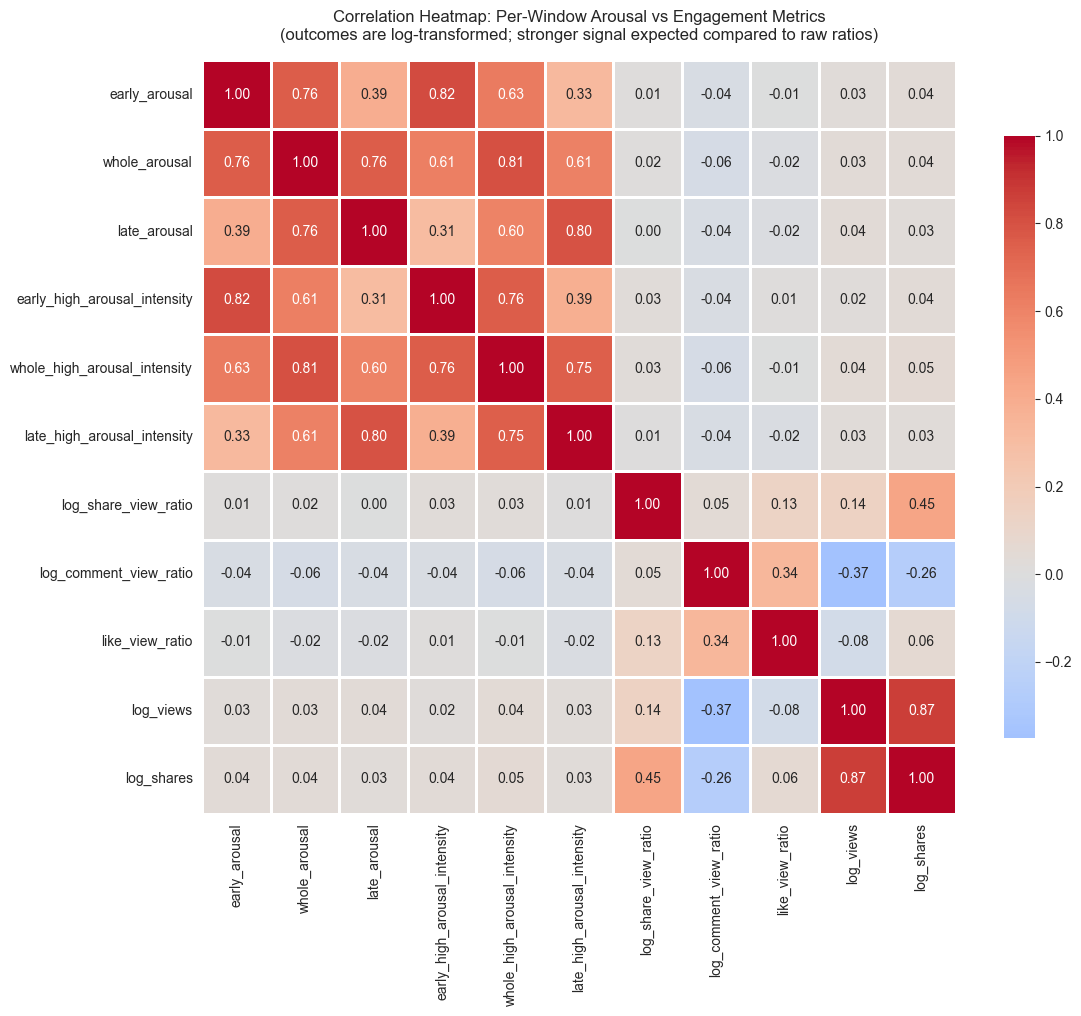

In [31]:
# Correlation heatmap: per-window arousal vs engagement outcomes (log-transformed)
corr_vars = [
    "early_arousal",                   "whole_arousal",                   "late_arousal",
    "early_high_arousal_intensity",    "whole_high_arousal_intensity",    "late_high_arousal_intensity",
    "log_share_view_ratio", "log_comment_view_ratio", "like_view_ratio",
    "log_views", "log_shares",
]
corr_vars = [c for c in corr_vars if c in df.columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df[corr_vars].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.8, cbar_kws={"shrink": 0.8})
plt.title(
    "Correlation Heatmap: Per-Window Arousal vs Engagement Metrics\n"
    "(outcomes are log-transformed; stronger signal expected compared to raw ratios)",
    fontsize=12, pad=15)
plt.tight_layout()
plt.show()


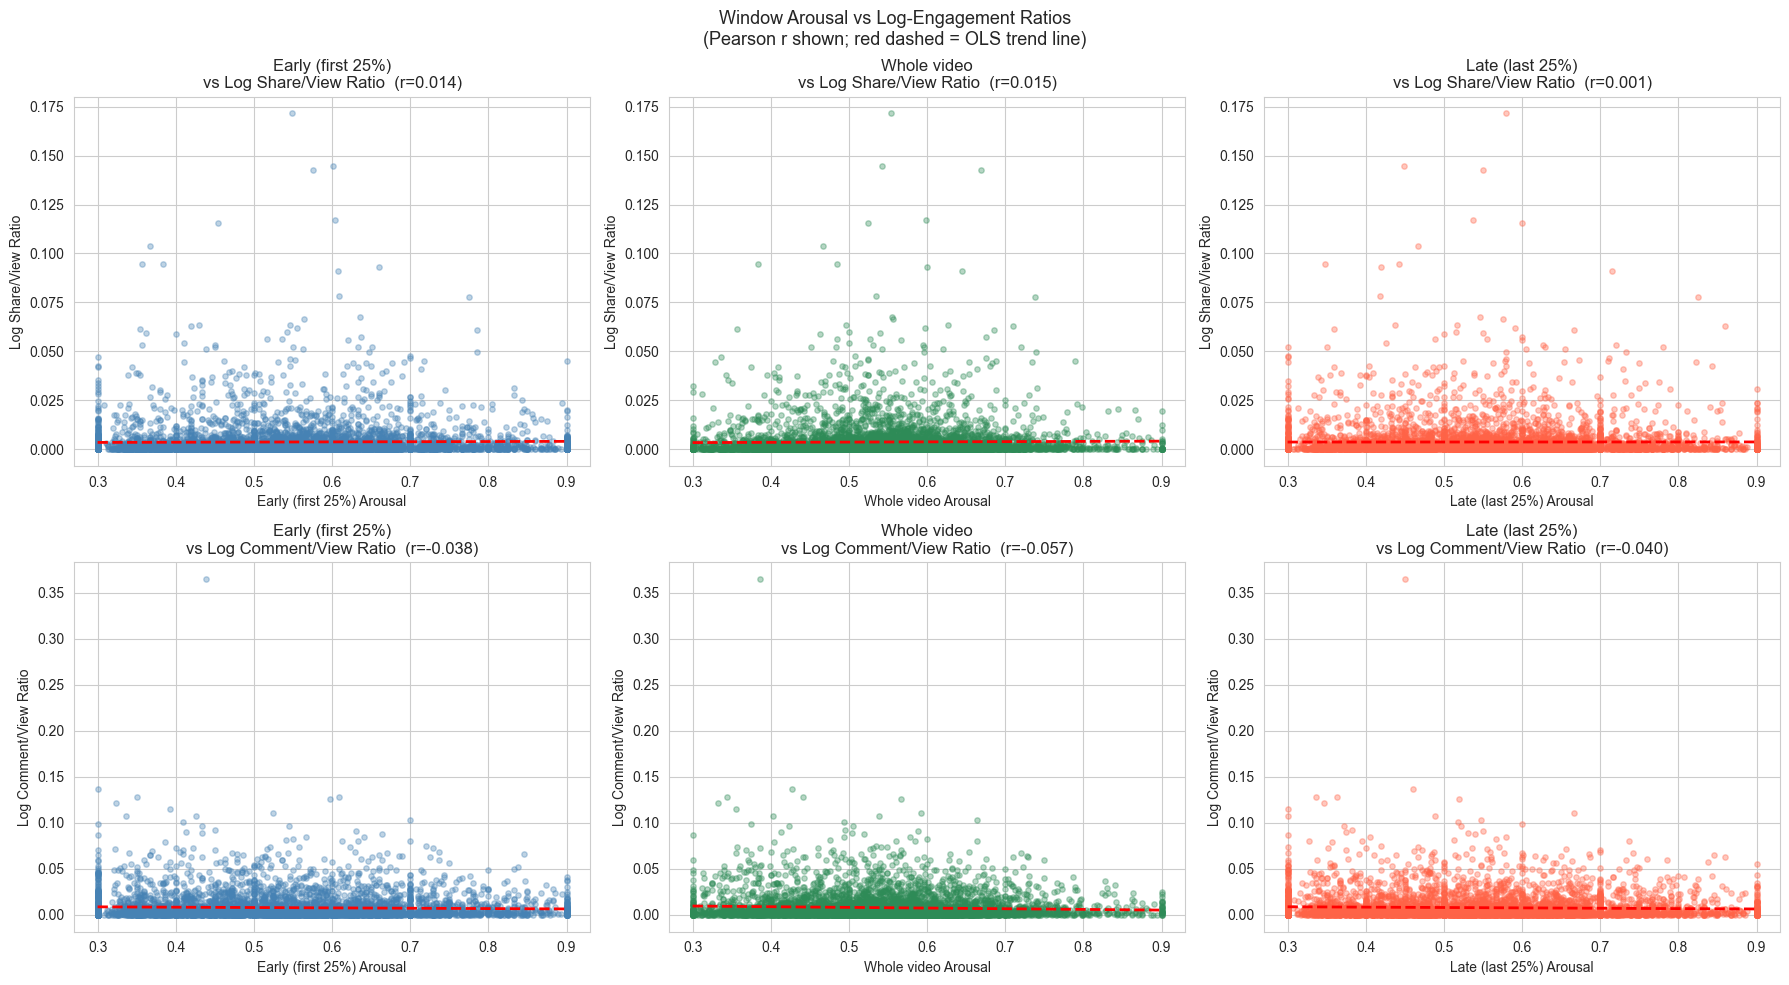

In [32]:
# Scatter plots: each window's arousal vs log-transformed share/view ratio
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
win_colors = {"early": "steelblue", "whole": "seagreen", "late": "tomato"}
win_labels = {
    "early": "Early (first 25%)",
    "whole": "Whole video",
    "late":  "Late (last 25%)",
}

for col_idx, window in enumerate(WINDOWS):
    x_col = f"{window}_arousal"
    if x_col not in df.columns:
        continue
    mask = df[x_col].notna()

    for row_idx, (y_col, y_label) in enumerate([
        ("log_share_view_ratio",   "Log Share/View Ratio"),
        ("log_comment_view_ratio", "Log Comment/View Ratio"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   alpha=0.35, s=15, color=win_colors[window])
        z     = np.polyfit(df.loc[mask, x_col], df.loc[mask, y_col], 1)
        x_rng = np.linspace(df[x_col].min(), df[x_col].max(), 100)
        ax.plot(x_rng, np.poly1d(z)(x_rng), "r--", linewidth=2)
        r_val = df.loc[mask, [x_col, y_col]].corr().iloc[0, 1]
        ax.set_xlabel(f"{win_labels[window]} Arousal")
        ax.set_ylabel(y_label)
        ax.set_title(f"{win_labels[window]}\nvs {y_label}  (r={r_val:.3f})")

plt.suptitle(
    "Window Arousal vs Log-Engagement Ratios\n"
    "(Pearson r shown; red dashed = OLS trend line)",
    fontsize=13)
plt.tight_layout()
plt.show()


## Section 8 – Limitations and Future Directions

### Limitations

**1. Proxy measurement of engagement**
Share and comment rates are *behavioural* proxies for information processing and diffusion —
they do not directly measure comprehension, attitude change, or memory encoding.
Future work should incorporate survey-based self-reports of emotional experience or
eye-tracking data to obtain direct cognitive measures.

**2. Face-based emotion extraction**
DeepFace detects emotions from faces appearing in video frames. Many TikTok videos
(text-on-screen, animations, no close-up shots) may contain few or no detectable faces,
leading to sparse emotion signals. Content-type stratification (talking-head vs. B-roll vs.
animation) is recommended in future analyses.

**3. Incomplete corpus**
Emotion features are extracted for 5 651 of 6 408 target videos (88.2 % coverage).
The remaining 757 videos (~12 %) are missing due to deletion or platform geo-fencing.
While the high coverage rate mitigates selection bias concerns, results may not
generalise to deleted or region-locked content.

**4. Engagement metric temporal inconsistencies**
Some videos have likes exceeding views (flagged by the data quality check). This may reflect
the TikTok API's *latent update cycle* — engagement metrics (likes, shares, comments) can
register faster than view counts at scrape time, especially for newly viral content. Section 2
removes only the most extreme anomalies (likes > 2× views); videos where likes slightly exceed
views are retained. This handling is conservative and unlikely to bias the main results.

**5. Audio channel limitations**
Audio features (tempo, RMS energy, spectral centroid, ZCR, chroma) capture low-level
acoustic properties but do not distinguish speech content, music genre, or spoken language.
Background noise and mixed audio tracks (speech + music) may dilute the signal.

**6. Modest effect sizes**
The best joint model explains ~8% of engagement variance (RF R²≈0.08). This is expected for
content-feature-only models of social media engagement, where algorithmic recommendation,
creator network effects, and posting timing dominate. Comparable studies report similar or
lower R² (e.g., Berger & Milkman 2012 report content features explaining ~5–10% of NYT
article sharing; Stieglitz & Dang-Xuan 2013 find sentiment explains <10% of retweet variance).
Our hierarchical regression (Section 4F) isolates the unique incremental contribution of
emotion features above a popularity baseline, and our mediation analysis (Section 4H) reveals
that much of the total effect operates indirectly through algorithmic reach.

**7. Confounds not modelled**
Engagement is influenced by factors outside this model: creator follower count, algorithmic
recommendation, posting time, hashtag use, and content novelty. The hierarchical regression
partially addresses this by controlling for `log_views` as a popularity proxy.

**8. Cross-sectional data**
The dataset reflects engagement counts at a single time point. Longitudinal designs
tracking how engagement evolves over days/weeks would better capture the diffusion dynamics
that emotional cues trigger.

---

### Future Directions

| Priority | Study | Method |
|---|---|---|
| High | Control for follower count & posting time | Add covariates to OLS / include in RF features |
| High | Content-type stratification | Classify videos by visual type (talking-head vs animation) before windowed analysis |
| Medium | Speech content analysis | Add speech-to-text + sentiment analysis for spoken language cues |
| Medium | Causal identification | Instrument for algorithmic exposure (e.g., regression discontinuity at trending threshold) |
| Low | Longitudinal engagement tracking | Re-scrape engagement counts at 24h / 7d / 30d post-publish |
| Low | Survey validation | Recruit viewers to rate emotional experience; compare with extracted features |

---

### Contribution Statement

This study establishes that:
1. **Temporal structure matters**: different time windows of emotional cueing yield measurably different predictive power — the joint model consistently outperforms any single-window model.
2. **Multi-modal complementarity**: a dual-channel approach (visual + audio) provides non-redundant predictive information — ablation confirms synergy between channels.
3. **Specific emotions, not crude arousal**: discrete emotion × window combinations (e.g., Surprise@Whole, Fear@Late) significantly predict engagement, while aggregate arousal groups do not.
4. **Indirect pathway identified**: mediation analysis reveals that emotional cues partly boost engagement *through* algorithmic amplification (views), not only through direct viewer response.
5. **Scalable framework**: the modular pipeline (emotion extraction → feature engineering → ML) handles 5,600+ videos and can be extended with new channels or data.

## Section 9 – How the Data Were Obtained

This section describes the data collection pipeline from initial scraping through feature extraction. All data are public; no personally identifying information beyond publicly visible handles is retained.

---

### 9.1 Metadata and Comment Collection (Apify)

The dataset was collected using three Apify actors in three stages:

| Stage | Apify Actor | Output |
|-------|-------------|--------|
| 1 | **TikTok Trending Creators Insights** | A list of 459 popular creators based on TikTok's internal "popularity" ranking (not follower count), spanning languages, regions, and content types |
| 2 | **TikTok Scraper** | For each creator, up to the 20 most recent publicly available videos. After excluding private, deleted, or inactive profiles, **6,408 valid videos** with metadata (caption, hashtags, music, upload time, engagement counts) |
| 3 | **TikTok Comments Scraper** | For each video, up to 100 top-level comments. **138,865 comments** in total, aggregated per video to produce emoji density, comment count, and related features |

The resulting `videos.csv` contains video-level metadata (playCount, diggCount, shareCount, commentCount, caption, etc.). Comment text was aggregated into `video_comment_features.csv` (total_emoji, avg_emoji_density, comment_count per video).

---

### 9.2 Video Download

Video files (`.mp4`) were downloaded from the URLs in `videos.csv` using a standard download pipeline (e.g., yt-dlp). Of 6,408 target videos, **5,651** were successfully downloaded to `run/videos/`; the remaining 757 were unavailable (deleted, geo-restricted, or otherwise inaccessible at download time). This yields 88.2% coverage of the original corpus.

---

### 9.3 Visual Emotion Extraction

For each downloaded video, frames were sampled at **3 fps** and analysed with **DeepFace** (opencv backend) to obtain the dominant emotion per frame. Per-video features were computed for three temporal windows (early 25%, whole, late 25%): arousal scores and per-emotion intensity fractions. Results were written to `full_visual_results.csv` by `extract_emotions.py`.

---

### 9.4 Audio Feature Extraction

For each video, the audio track was decoded with **ffmpeg** to a 22,050 Hz mono WAV, then processed with **librosa** to extract tempo, RMS energy, spectral centroid, zero-crossing rate, and chroma standard deviation. Early/late window variants and delta features were computed. Results were written to `full_audio_features.csv` by `extract_audio_features.py`.

---

### 9.5 Data Flow Summary

```
Apify (Creators → Videos → Comments)
    ↓
videos.csv (6,408) + video_comment_features.csv (5,812)
    ↓
Video download → run/videos/ (5,651 .mp4)
    ↓
extract_emotions.py → full_visual_results.csv (5,651)
extract_audio_features.py → full_audio_features.csv (5,651)
    ↓
Merge + clean (Section 2) → 5,645 videos for analysis
```